# `GEA` demo: masking the interactome

This notebook is a variant of the disease-graph demo. Instead of handing the GNN one induced subgraph per disease, the disease is a **mask over a single shared interactome**: the STRING protein-protein interaction network is the only graph there is, and a disease is a 0/1 vector over its proteins plus a confidence score.

-----

**Main objectives:**

- Fetch disease-associated gene sets from the [DISEASES](https://diseases.jensenlab.org/) database and the global protein-protein interaction network from [STRING](https://string-db.org/).
- Turn every disease into a mask $m^{(d)}$ and a confidence vector $c^{(d)}$ over STRING proteins, and cut the **context graph** the GNN actually reads: the disease genes plus the 1-hop neighbourhood around them, $V_d^+ = D_d \cup N_1(D_d)$.
- Give every node the feature $x_i^{(d)} = [e_i, m_i^{(d)}, c_i^{(d)}]$ — the whitened ESM-2 embedding as protein identity, the mask and the confidence as disease state.
- Train a GNN whose every layer is **FiLM-conditioned** on $(m_i^{(d)}, c_i^{(d)})$, against (1) held-out protein interactions and (2) a disease-context contrastive objective separating disease genes from their own local background.
- Building explainability using GEA at the node-, edge- and graph-level embeddings (i.e. training 3 Sparse Autoencoders (SAEs) and attributing features to a known ontology for the genes).

## Fetching data from databases

### Exploring the DISEASES database

#### Setup

In [1]:
from pathlib import Path

import pandas as pd
import requests

DATA_DIR = Path("data/diseases")
DATA_DIR.mkdir(parents=True, exist_ok=True)

#### The DISEASES data

DISEASES publishes one flat file per evidence channel — no API key needed. We use `integrated`, which combines curated knowledge, GWAS and text mining and gives the best gene coverage per disease.

Each row is one (protein, disease) association with a confidence score from 0 (low) to 5 (high) stars.

In [2]:
def download_file(url, dest):
    if dest.exists():
        return dest
    print(f"downloading {url}")
    with requests.get(url, stream=True, timeout=180, headers={"User-Agent": "gea-diseases-demo/1.0"}) as resp:
        resp.raise_for_status()
        with open(dest, "wb") as fh:
            for chunk in resp.iter_content(1 << 20):
                fh.write(chunk)
    return dest


DISEASES_URL = "https://download.jensenlab.org/human_disease_integrated_full.tsv"
DISEASES_FILE = download_file(DISEASES_URL, DATA_DIR / "human_disease_integrated_full.tsv")

print(f"{DISEASES_FILE.name}: {DISEASES_FILE.stat().st_size / 1e6:.0f} MB")

human_disease_integrated_full.tsv: 645 MB


The `integrated` channel has five columns and no header row: a STRING protein id, the gene symbol, a Disease Ontology id (DOID), the disease name, and the confidence score.

The `doid` column also carries a few non-DOID entries (ICD10 chapter codes, one OMIM id) that the Disease Ontology can't place — we keep DOID-prefixed rows only.

In [3]:
COLUMNS = ["gene_id", "gene_symbol", "doid", "doid_name", "conf"]

diseases = pd.read_csv(DISEASES_FILE, sep="\t", header=None, names=COLUMNS)
diseases = diseases[diseases["doid"].str.startswith("DOID:")].reset_index(drop=True)
diseases.head()

,gene_id,gene_symbol,doid,doid_name,conf
0,18S_rRNA,18S_rRNA,DOID:9643,Babesiosis,3.631
1,18S_rRNA,18S_rRNA,DOID:1398,Parasitic infectious disease,3.524
2,18S_rRNA,18S_rRNA,DOID:2789,Parasitic protozoa infectious disease,3.518
3,18S_rRNA,18S_rRNA,DOID:4,Disease,3.396
4,18S_rRNA,18S_rRNA,DOID:0050117,Disease by infectious agent,3.316


We could also check the amount of entries and each type of variable inside the `diseases` dataframe.

In [4]:
print(f"{len(diseases):,} rows")
print(diseases.dtypes)

7,095,843 rows
gene_id         object
gene_symbol     object
doid            object
doid_name       object
conf           float64
dtype: object


### Filtering diseases

#### Confidence of genes being associated to a disease

The `conf` column is a 0–5 star scale: higher means more confident the gene is really associated with the disease.

count    7.095843e+06
mean     1.089939e+00
std      5.735548e-01
min      5.000000e-01
25%      6.860000e-01
50%      9.320000e-01
75%      1.325000e+00
max      5.000000e+00
Name: conf, dtype: float64


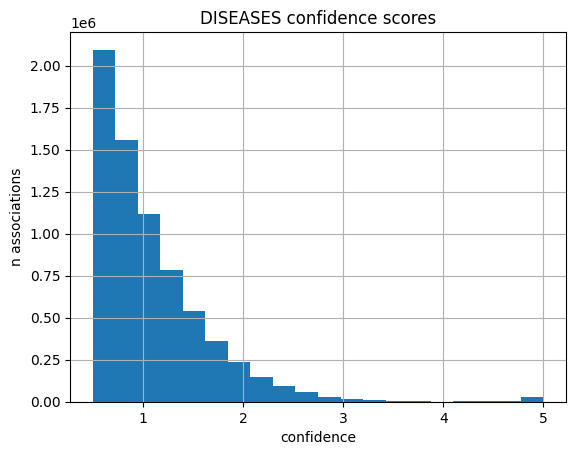

In [5]:
import matplotlib.pyplot as plt

print(diseases["conf"].describe())

diseases["conf"].hist(bins=20)
plt.xlabel("confidence"); plt.ylabel("n associations"); plt.title("DISEASES confidence scores")
plt.show()

Most of the mass sits below 2 stars (thin text-mining evidence). DISEASES' own documentation treats confidence ≥ 2 as the floor for a believable association, so we apply it before looking further.

In [6]:
MIN_CONF = 2.0

n_before = len(diseases)
diseases_conf = diseases[diseases["conf"] >= MIN_CONF].reset_index(drop=True)
print(f"{n_before:,} → {len(diseases_conf):,} rows with confidence >= {MIN_CONF}")

7,095,843 → 468,872 rows with confidence >= 2.0


We can now evaluate how many distinct diseases we have after the filtering of low confident genes and distinct genes associated to any disease.

In [7]:
print(f"{diseases_conf['doid'].nunique():,} distinct diseases")
print(f"{diseases_conf['gene_symbol'].nunique():,} distinct genes")

7,886 distinct diseases
14,540 distinct genes


#### Redundant diseases by gene size

Some entries are specific diseases with a handful of genes; others are broad umbrella terms from the Disease Ontology (e.g. "disease", "cancer") that list thousands. Worth seeing both ends.

In [8]:
genes_per_disease = (
    diseases_conf.groupby(["doid", "doid_name"])["gene_symbol"]
    .nunique()
    .sort_values(ascending=False)
)

genes_per_disease.describe()

count     7886.000000
mean        59.456252
std        312.122357
min          1.000000
25%          2.000000
50%          6.000000
75%         20.000000
max      10619.000000
Name: gene_symbol, dtype: float64

In [9]:
print("Largest gene sets:")
print(genes_per_disease.head(10))

print("\nSmallest gene sets:")
print(genes_per_disease.tail(10))

Largest gene sets:
doid          doid_name                        
DOID:4        Disease                              10619
DOID:7        Disease of anatomical entity          9033
DOID:630      Genetic disease                       5524
DOID:14566    Disease of cellular proliferation     5378
DOID:162      Cancer                                5263
DOID:863      Nervous system disease                5141
DOID:0050686  Organ system cancer                   4828
DOID:0050177  Monogenic disease                     4085
DOID:331      Central nervous system disease        3922
DOID:77       Gastrointestinal system disease       3816
Name: gene_symbol, dtype: int64

Smallest gene sets:
doid          doid_name                   
DOID:0050116  Tinea imbricata                 1
DOID:0050141  Intestinal botulism             1
DOID:0050490  Parenchymatous neurosyphilis    1
DOID:0050192  Nipah virus encephalitis        1
DOID:0050198  Chapare hemorrhagic fever       1
DOID:0050202  Lujo hemorrha

Diseases with very few genes carry too little signal, and diseases with thousands are Disease Ontology groupings (`Disease`, `Cancer`, `Genetic disease`, …) rather than specific diseases. We keep gene-set sizes in a reasonable range in between.

In [10]:
MIN_GENES_PER_DISEASE = 50
MAX_GENES_PER_DISEASE = 2000

too_small = genes_per_disease[genes_per_disease < MIN_GENES_PER_DISEASE]
too_large = genes_per_disease[genes_per_disease > MAX_GENES_PER_DISEASE]
keep_dois = genes_per_disease[
    (genes_per_disease >= MIN_GENES_PER_DISEASE) & (genes_per_disease <= MAX_GENES_PER_DISEASE)
].index.get_level_values("doid")

n_before = diseases_conf["doid"].nunique()
diseases_range = diseases_conf[diseases_conf["doid"].isin(keep_dois)].reset_index(drop=True)

print(f"dropped {len(too_small):,} diseases with < {MIN_GENES_PER_DISEASE} genes")
print(f"dropped {len(too_large):,} diseases with > {MAX_GENES_PER_DISEASE} genes, e.g. "
      + ", ".join(name for _, name in too_large.index[:5]))
print(f"\n{n_before:,} → {diseases_range['doid'].nunique():,} diseases kept")

dropped 6,904 diseases with < 50 genes
dropped 44 diseases with > 2000 genes, e.g. Disease, Disease of anatomical entity, Genetic disease, Disease of cellular proliferation, Cancer

7,886 → 938 diseases kept


#### Removing diseases with identical gene sets

Some DOIDs are near-synonyms that DISEASES' text mining cannot tell apart (e.g. "Leiomyosarcoma" and "Smooth muscle cancer") and end up with the exact same gene set under two different labels. We keep one representative per group of diseases sharing an identical gene set.

In [11]:
gene_sets = (
    diseases_range.groupby(["doid", "doid_name"])["gene_symbol"]
    .apply(frozenset)
    .reset_index()
)

dup_mask = gene_sets["gene_symbol"].duplicated(keep=False)
twin_groups = gene_sets[dup_mask].groupby("gene_symbol")["doid"].apply(list)

print(f"{dup_mask.sum():,} diseases in {len(twin_groups):,} groups share an identical gene set, e.g.:")
names_by_doid = gene_sets.set_index("doid")["doid_name"]
for dois in twin_groups.head(5):
    print("   " + " = ".join(names_by_doid.loc[dois]))

# one representative per group (the alphabetically first doid), the rest are dropped as duplicates
drop_dois = {doid for dois in twin_groups for doid in sorted(dois)[1:]}

n_before = diseases_range["doid"].nunique()
diseases_unique = diseases_range[~diseases_range["doid"].isin(drop_dois)].reset_index(drop=True)
print(f"\n{n_before:,} → {diseases_unique['doid'].nunique():,} diseases after dropping {len(drop_dois):,} twins")

36 diseases in 18 groups share an identical gene set, e.g.:
   Glycogen metabolism disorder = Glycogen storage disease
   Bile duct adenocarcinoma = Cholangiocarcinoma
   Insulinoma = Pancreatic cystadenoma
   Uveal cancer = Uveal melanoma
   Cystadenocarcinoma = Malignant cystadenoma

938 → 920 diseases after dropping 18 twins


We can also look into one specific disease. As an example, type 2 diabetes mellitus (`DOID:9352`) and its associated genes, ranked by confidence, are showcased.

In [12]:
doid = "DOID:9352"
example = diseases_unique[diseases_unique["doid"] == doid].sort_values("conf", ascending=False)

print(f"{example['doid_name'].iloc[0]}: {len(example)} associations, "
      f"{example['gene_symbol'].nunique()} distinct genes")
example.head(15)

Type 2 diabetes mellitus: 1117 associations, 1117 distinct genes


,gene_id,gene_symbol,doid,doid_name,conf
23783,ENSP00000240652,IAPP,DOID:9352,Type 2 diabetes mellitus,4.708
29359,ENSP00000252486,APOE,DOID:9352,Type 2 diabetes mellitus,4.670
158136,ENSP00000363827,HSPG2,DOID:9352,Type 2 diabetes mellitus,4.344
32777,ENSP00000255040,APCS,DOID:9352,Type 2 diabetes mellitus,4.337
185853,ENSP00000380432,INS,DOID:9352,Type 2 diabetes mellitus,4.000
196197,ENSP00000389814,ADIPOQ,DOID:9352,Type 2 diabetes mellitus,4.000
93795,ENSP00000312652,LEP,DOID:9352,Type 2 diabetes mellitus,4.000
195064,ENSP00000387662,GCG,DOID:9352,Type 2 diabetes mellitus,4.000
154168,ENSP00000362353,GLP1R,DOID:9352,Type 2 diabetes mellitus,4.000
84332,ENSP00000303830,INSR,DOID:9352,Type 2 diabetes mellitus,3.986


Let's save the filtered dataset with all disease-associated gene sets into our data folder.

In [13]:
diseases_unique.to_csv(DATA_DIR / "diseases_filtered.tsv", sep="\t", index=False)

### Fetching protein-protein interaction networks from STRING

#### Setup

In [14]:
from pathlib import Path

import pandas as pd
import requests

DATA_DIR = Path("data/diseases")
STRING_DIR = DATA_DIR / "string"
STRING_DIR.mkdir(parents=True, exist_ok=True)

diseases = pd.read_csv(DATA_DIR / "diseases_filtered.tsv", sep="\t")
print(f"{len(diseases):,} associations | {diseases['doid'].nunique():,} diseases | "
      f"{diseases['gene_id'].nunique():,} proteins")

260,212 associations | 920 diseases | 9,852 proteins


#### The STRING data

[STRING](https://string-db.org/) publishes one flat file of all pairwise interaction scores per species, so no API key needed either for this case. Each row is one (protein, protein) pair with a combined confidence score from 0 to 1000, aggregating evidence from experiments, curated databases, co-expression, text mining and more.

In [15]:
def download_file(url, dest):
    if dest.exists():
        return dest
    print(f"downloading {url}")
    with requests.get(url, stream=True, timeout=180, headers={"User-Agent": "gea-diseases-demo/1.0"}) as resp:
        resp.raise_for_status()
        with open(dest, "wb") as fh:
            for chunk in resp.iter_content(1 << 20):
                fh.write(chunk)
    return dest

STRING_URL = "https://stringdb-downloads.org/download/protein.links.v12.0/9606.protein.links.v12.0.txt.gz"
STRING_FILE = download_file(STRING_URL, STRING_DIR / "9606.protein.links.v12.0.txt.gz")

print(f"{STRING_FILE.name}: {STRING_FILE.stat().st_size / 1e6:.0f} MB")

9606.protein.links.v12.0.txt.gz: 83 MB


The dataframe has one row per interacting protein pair. STRING ids carry a species prefix (`9606.` for human), which we drop so they match the protein ids already in our disease table.

In [16]:
string_links = pd.read_csv(STRING_FILE, sep=" ", compression="gzip")
string_links["protein1"] = string_links["protein1"].str.removeprefix("9606.")
string_links["protein2"] = string_links["protein2"].str.removeprefix("9606.")
string_links.head()

,protein1,protein2,combined_score
0,ENSP00000000233,ENSP00000356607,173
1,ENSP00000000233,ENSP00000427567,154
2,ENSP00000000233,ENSP00000253413,151
3,ENSP00000000233,ENSP00000493357,471
4,ENSP00000000233,ENSP00000324127,201


As the DISEASES dataframe, we can also look into the amount of rows (protein interactions) and the columns type the dataframe has.

In [17]:
print(f"{len(string_links):,} rows")
print(string_links.dtypes)

13,715,404 rows
protein1          object
protein2          object
combined_score     int64
dtype: object


### Filtering interactions based on confidence score

#### High confidence interaction filter

The overall confidence score that is made aggregating every evidence channel of a protein-protein interaction in STRING is given by `combined_score` (its range is 0–1000). STRING's own "high confidence" cutoff is 700.

count    1.371540e+07
mean     2.686240e+02
std      1.569828e+02
min      1.500000e+02
25%      1.710000e+02
50%      2.090000e+02
75%      2.980000e+02
max      9.990000e+02
Name: combined_score, dtype: float64


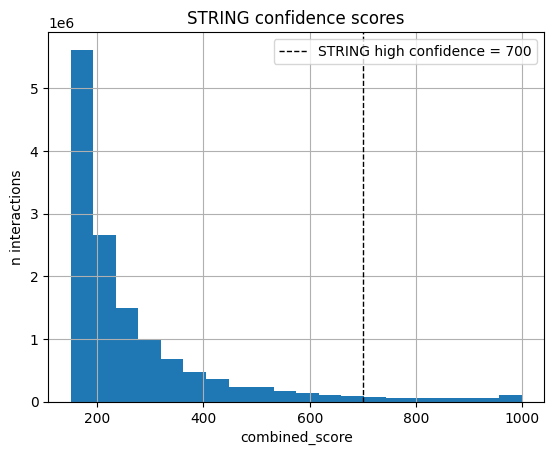

In [18]:
from matplotlib import pyplot as plt

print(string_links["combined_score"].describe())

string_links["combined_score"].hist(bins=20)
plt.axvline(700, color="k", ls="--", lw=1, label="STRING high confidence = 700")
plt.xlabel("combined_score"); plt.ylabel("n interactions"); plt.title("STRING confidence scores")
plt.legend(); plt.show()

We keep only high-confidence interactions (`combined_score >= 700`, STRING's own "high confidence" band). Medium confidence (`>= 400`) would keep far more edges, but pulls in a lot of weaker, text-mining-only evidence — and we're already leaning on DISEASES' text-mined associations for the disease genes, so keeping the network side clean avoids compounding two noisy sources.

In [19]:
STRING_MIN_SCORE = 700

n_before = len(string_links)
string_links = string_links[string_links["combined_score"] >= STRING_MIN_SCORE].reset_index(drop=True)
print(f"{n_before:,} → {len(string_links):,} interactions with combined_score >= {STRING_MIN_SCORE}")

13,715,404 → 473,860 interactions with combined_score >= 700


We can evaluate how many unique proteins and interactions we end up on the final set.

In [20]:
n_proteins = pd.concat([string_links["protein1"], string_links["protein2"]]).nunique()
print(f"{n_proteins:,} distinct proteins")
print(f"{len(string_links):,} interactions")

16,201 distinct proteins
473,860 interactions


#### Interactions per protein

Like the disease gene sets, this is heavy-tailed: most proteins have a handful of high-confidence partners, while a few hub proteins have thousands.

In [21]:
interactions_per_protein = (
    pd.concat([string_links["protein1"], string_links["protein2"]])
    .value_counts()
)

print(interactions_per_protein.describe())
print("\nMost connected proteins:")
print(interactions_per_protein.head(10))

count    16201.000000
mean        58.497624
std         91.458814
min          2.000000
25%          8.000000
50%         26.000000
75%         70.000000
max       1532.000000
Name: count, dtype: float64

Most connected proteins:
ENSP00000269305    1532
ENSP00000272317    1178
ENSP00000388107    1042
ENSP00000275493    1012
ENSP00000495360     930
ENSP00000244537     904
ENSP00000333277     904
ENSP00000494750     876
ENSP00000451828     870
ENSP00000431822     846
Name: count, dtype: int64


As an example, `INS` (insulin, `ENSP00000380432`) — one of the type 2 diabetes genes from before — and its highest-confidence interaction partners.

In [22]:
protein = "ENSP00000380432"
example = string_links[(string_links["protein1"] == protein) | (string_links["protein2"] == protein)]
example = example.sort_values("combined_score", ascending=False)

print(f"{protein}: {len(example)} interactions")
example.head(15)

ENSP00000380432: 612 interactions


,protein1,protein2,combined_score
340952,ENSP00000380432,ENSP00000265986,999
464646,ENSP00000497069,ENSP00000380432,999
340994,ENSP00000380432,ENSP00000304895,999
340899,ENSP00000380432,ENSP00000376637,999
146811,ENSP00000303830,ENSP00000380432,999
340900,ENSP00000380432,ENSP00000497069,999
341026,ENSP00000380432,ENSP00000303830,999
91784,ENSP00000265986,ENSP00000380432,999
327055,ENSP00000376637,ENSP00000380432,999
341059,ENSP00000380432,ENSP00000295897,999


We can save these protein-protein interactions on our data folder.

In [23]:
string_links.to_csv(DATA_DIR / "string_filtered.tsv", sep="\t", index=False)

## Masking the interactome

### Building the disease context graphs

#### Setup

In [24]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("data/diseases")             # shared with the disease-graph demo: downloads + filtered tables
STRING_DIR = DATA_DIR / "string"
OUT_DIR = Path("data/mask-the-interactome")  # everything this notebook produces
OUT_DIR.mkdir(parents=True, exist_ok=True)

diseases = pd.read_csv(DATA_DIR / "diseases_filtered.tsv", sep="\t")
string_links = pd.read_csv(DATA_DIR / "string_filtered.tsv", sep="\t")

print(f"{diseases['doid'].nunique():,} diseases | {diseases['gene_id'].nunique():,} disease genes")
print(f"{len(string_links):,} interactions | "
      f"{pd.concat([string_links['protein1'], string_links['protein2']]).nunique():,} proteins")

920 diseases | 9,852 disease genes
473,860 interactions | 16,201 proteins


#### The disease as a mask, not as a graph

There is one graph, $G = (V, E)$: the high-confidence STRING interactome. A disease $d$ is not a graph of its own — it is a pair of vectors over that graph's proteins:

- a **mask** $m^{(d)} \in \{0, 1\}^{|V|}$, 1 for the proteins DISEASES associates with $d$,
- a **confidence** $c^{(d)}$, the DISEASES star score (2-5) for those proteins and 0 everywhere else.

Passing the whole interactome through the GNN once per disease would be wasteful — most of it is nowhere near the mask — so what the model actually reads is the **context graph**: the subgraph induced on $V_d^+ = D_d \cup N_1(D_d)$, the disease genes together with the STRING partners immediately around them. That neighbourhood is what makes the rest of the notebook possible: it gives every disease a *local background* of proteins sitting in the same region of the interactome that were never associated with the disease.

$N_1(D_d)$ taken in full is too big to be useful — the 1-hop neighbourhood of a median disease already covers 3,400 of the 16,201 STRING proteins and a large one over 11,000, so every "context" would be most of the interactome. We keep each disease gene's `K_NEIGHBOURS` highest-confidence partners instead. At K = 2 the background comes out roughly the same size as the disease gene set itself — a balanced, genuinely local contrast — and the partners kept are the *hardest* available negatives: proteins bound tightly to a disease gene that the disease was nonetheless never annotated with. Some of them are presumably disease-relevant and simply unstudied; that is a feature of the setup rather than a flaw in it, and it is exactly what the model is later asked to score.

In [25]:
import networkx as nx

G_string = nx.from_pandas_edgelist(string_links, "protein1", "protein2", edge_attr="combined_score")
print(f"STRING interactome: {G_string.number_of_nodes():,} proteins | {G_string.number_of_edges():,} interactions")

K_NEIGHBOURS = 2  # highest-confidence STRING partners kept per disease gene

# top-K partners of every protein, ranked by combined_score — computed once over the whole interactome
top_partners = {
    protein: [p for p, _ in sorted(G_string[protein].items(),
                                   key=lambda kv: -kv[1]["combined_score"])[:K_NEIGHBOURS]]
    for protein in G_string.nodes
}

gene_sets = diseases.groupby(["doid", "doid_name"])["gene_id"].apply(set)
conf_by_disease = {
    doid: dict(zip(group["gene_id"], group["conf"]))
    for doid, group in diseases.drop_duplicates(["doid", "gene_id"]).groupby("doid")
}

context_graphs, rows = {}, []
for (doid, doid_name), genes in gene_sets.items():
    seeds = genes & G_string.nodes                                      # D_d, restricted to STRING
    if not seeds:
        continue
    background = set().union(*(top_partners[p] for p in seeds)) - seeds  # N_1(D_d) \ D_d
    G = G_string.subgraph(seeds | background).copy()                     # V_d^+

    conf = conf_by_disease[doid]
    nx.set_node_attributes(G, {p: float(p in seeds) for p in G.nodes}, "m")
    nx.set_node_attributes(G, {p: float(conf.get(p, 0.0)) for p in G.nodes}, "c")

    context_graphs[doid] = G
    rows.append({"doid": doid, "doid_name": doid_name,
                 "n_nodes": G.number_of_nodes(), "n_edges": G.number_of_edges(),
                 "n_seed": len(seeds), "n_background": G.number_of_nodes() - len(seeds)})

graph_sizes = pd.DataFrame(rows).sort_values("n_nodes", ascending=False)
print(f"\n{len(context_graphs):,} disease context graphs built")

STRING interactome: 16,201 proteins | 236,930 interactions

920 disease context graphs built


#### Context graph sizes

Unlike an induced disease subgraph, a context graph has no isolated nodes by construction: every background protein is in it because it partners a disease gene, and every disease gene that STRING knows at all keeps its own partners. The sizes below are split into the masked part (`n_seed`) and the local background (`n_background`).

In [26]:
print(graph_sizes[["n_nodes", "n_edges", "n_seed", "n_background"]].describe())

ratio = graph_sizes["n_background"] / graph_sizes["n_seed"]
print(f"\nbackground / disease-gene ratio: median {ratio.median():.2f}")

print("\nLargest context graphs:")
print(graph_sizes.head(10).to_string(index=False))

print("\nSmallest context graphs:")
print(graph_sizes.tail(10).to_string(index=False))

           n_nodes       n_edges       n_seed  n_background
count   920.000000    920.000000   920.000000    920.000000
mean    504.004348   6554.976087   269.680435    234.323913
std     560.797004   9626.091770   340.604238    223.240370
min      87.000000    195.000000    46.000000     28.000000
25%     155.000000    936.250000    70.750000     86.000000
50%     266.000000   2097.500000   126.000000    140.500000
75%     574.000000   7147.750000   285.250000    285.250000
max    3065.000000  48283.000000  1880.000000   1289.000000

background / disease-gene ratio: median 1.09

Largest context graphs:
        doid                        doid_name  n_nodes  n_edges  n_seed  n_background
DOID:0050155           Sensory system disease     3065    42684    1776          1289
   DOID:4194       Glucose metabolism disease     2903    46463    1866          1037
     DOID:18           Urinary system disease     2846    46623    1800          1046
    DOID:612 Primary immunodeficiency disease

Back to type 2 diabetes mellitus (`DOID:9352`) we have been using as an example, its context graph is showcased — masked disease genes and the local background that came in with them.

In [27]:
doid = "DOID:9352"
G = context_graphs[doid]
n_seed = int(sum(m for _, m in G.nodes(data="m")))

print(f"Type 2 diabetes mellitus: {n_seed} masked disease genes + "
      f"{G.number_of_nodes() - n_seed} local-background proteins")
print(f"  {G.number_of_nodes()} nodes, {G.number_of_edges()} edges in the context graph")

Type 2 diabetes mellitus: 1072 masked disease genes + 801 local-background proteins
  1873 nodes, 28013 edges in the context graph


### ESM-2 embeddings as a node flag

There is a huge problem on network analysis, and if the plan is to use graph to train graph neural networks then the model has no way to know the node identity. Therefore, we can flag each protein by concatenating a representative vector to its feature. In this case, we opt to use ESM-2 embeddings as a way to flag every protein. Here that matters twice over: the background proteins need an identity of exactly the same kind as the disease genes, or the mask would be readable straight off the node features and nothing below would mean anything.

#### Writing the protein list

The protein universe is wider than the disease genes alone — every background protein in a context graph needs an embedding too. `get_esm_protein_embeddings.py` looks sequences up by protein id directly, so there is still no gene mapping to do and no isoforms to aggregate. The disease-graph demo already embedded most of the disease genes, so we only ask for the proteins its file does not already cover.

In [28]:
import torch

universe = sorted({p for G in context_graphs.values() for p in G.nodes})
PROTEIN_LIST_FILE = OUT_DIR / "context_protein_ids.txt"
PROTEIN_LIST_FILE.write_text("\n".join(universe))

BASE_ESM_FILE = DATA_DIR / "esm_protein_embeddings.pt"
already = set(torch.load(BASE_ESM_FILE, weights_only=False)) if BASE_ESM_FILE.exists() else set()
missing = [p for p in universe if p not in already]

MISSING_LIST_FILE = OUT_DIR / "context_protein_ids_missing.txt"
MISSING_LIST_FILE.write_text("\n".join(missing))

print(f"{len(universe):,} proteins in the context-graph universe → {PROTEIN_LIST_FILE}")
print(f"{len(universe) - len(missing):,} already embedded in {BASE_ESM_FILE.name}")
print(f"{len(missing):,} still to embed → {MISSING_LIST_FILE}")

10,664 proteins in the context-graph universe → data/mask-the-interactome/context_protein_ids.txt
8,893 already embedded in esm_protein_embeddings.pt
1,771 still to embed → data/mask-the-interactome/context_protein_ids_missing.txt


#### Computing the embeddings

Run this from the repo root, in the `gea` conda environment. It only covers the proteins the
disease-graph demo has not already embedded, so this is a short run rather than a full pass over the
proteome:

```bash
python3 docs/scripts/get_esm_protein_embeddings.py \
    --protein-list docs/tutorial/data/mask-the-interactome/context_protein_ids_missing.txt \
    --out          docs/tutorial/data/mask-the-interactome/esm_protein_embeddings_context.pt \
    --species      human \
    --model        facebook/esm2_t33_650M_UR50D \
    --batch-size 8
```

The FASTA is already cached at `docs/tutorial/data/diseases/ensembl_pep.fa.gz`; pass it with `--fasta`
to skip the download entirely. This writes `{protein_id: tensor([1280])}` to
`esm_protein_embeddings_context.pt`, which the next cell merges with the disease-graph demo's file.
Come back here once it's finished.

#### Loading the embeddings

The two files are merged into one table — the disease-graph demo's, plus the top-up just computed — and written back out as a single file so `load_esm_protein_embeddings` has one place to read from.

Its random-Gaussian fallback for proteins missing from the file is a real hazard in this notebook. A protein carrying a random identity vector is trivially separable from one carrying a real ESM-2 embedding, and telling masked from unmasked proteins apart is precisely the model's job — a handful of random vectors would hand it a shortcut. So rather than let the fallback fire, we **drop** proteins with no embedding from the context graphs (retired ENSP ids that Ensembl's current proteome no longer carries) and only ever look up proteins the merged table actually has.

In [29]:
from gea.utils import load_esm_protein_embeddings

ESM_SOURCES = [BASE_ESM_FILE, OUT_DIR / "esm_protein_embeddings_context.pt"]

esm_table = {}
for source in ESM_SOURCES:
    if not source.exists():
        print(f"not found, run the command above first: {source}")
        continue
    part = torch.load(source, weights_only=False)
    new = {p: v for p, v in part.items() if p not in esm_table}
    esm_table.update(new)
    print(f"{source.name}: {len(part):,} proteins ({len(new):,} new)")

MERGED_ESM_FILE = OUT_DIR / "esm_protein_embeddings_merged.pt"
torch.save(esm_table, MERGED_ESM_FILE)

# drop proteins with no embedding instead of letting the loader invent one for them
unembedded = [p for p in universe if p not in esm_table]
for G in context_graphs.values():
    G.remove_nodes_from(unembedded)
    G.remove_nodes_from(list(nx.isolates(G)))
context_graphs = {doid: G for doid, G in context_graphs.items() if G.number_of_nodes() > 0}

all_proteins = sorted({p for G in context_graphs.values() for p in G.nodes})
esm_embeddings = load_esm_protein_embeddings(str(MERGED_ESM_FILE), all_proteins)
protein_to_esm = dict(zip(all_proteins, esm_embeddings))

print(f"\ndropped {len(unembedded):,} proteins with no ESM-2 embedding")
print(f"{len(all_proteins):,} proteins | {esm_embeddings.shape[1]}-dim ESM-2 embeddings | "
      f"{len(context_graphs):,} context graphs")

esm_protein_embeddings.pt: 9,197 proteins (9,197 new)
esm_protein_embeddings_context.pt: 1,606 proteins (1,606 new)


Loading ESM-2 embeddings: 100%|██████████| 10488/10488 [00:00<00:00, 183296.43it/s]

Found ESM-2 embeddings for 10488/10488 proteins.

dropped 165 proteins with no ESM-2 embedding
10,488 proteins | 1280-dim ESM-2 embeddings | 920 context graphs


#### Node features: `[m, c, esm_embedding]`

$x_i^{(d)} = [e_i, m_i^{(d)}, c_i^{(d)}]$ — identity first, then disease state. The mask and the confidence are the only disease-specific part of a node; $e_i$ is protein identity and is the same in every disease the protein appears in. The confidence is divided by 5 so both conditioning channels live in $[0, 1]$, with the local background sitting at $(0, 0)$.

In [30]:
CONF_SCALE = 5.0  # DISEASES stars run 0-5; background proteins stay at 0

for G in context_graphs.values():
    node_features = {
        p: torch.cat([
            torch.tensor([G.nodes[p]["m"], G.nodes[p]["c"] / CONF_SCALE]),
            protein_to_esm[p],
        ])
        for p in G.nodes
    }
    nx.set_node_attributes(G, node_features, "x")

print(f"node feature dim: {2 + esm_embeddings.shape[1]} "
      f"(1 mask + 1 confidence + {esm_embeddings.shape[1]} ESM-2 dims)")

node feature dim: 1282 (1 mask + 1 confidence + 1280 ESM-2 dims)


As before, `INS` (insulin, `ENSP00000380432`) in the type 2 diabetes mellitus context graph (`DOID:9352`) — this time next to one of the background proteins that came in with it.

In [31]:
G = context_graphs["DOID:9352"]
seed = "ENSP00000380432"
background = next((p for p in G.neighbors(seed) if G.nodes[p]["m"] == 0.0),
                  next(p for p in G.nodes if G.nodes[p]["m"] == 0.0))

for label, protein in [(f"{seed} (INS, masked)", seed), (f"{background} (background)", background)]:
    x = G.nodes[protein]["x"]
    print(f"{label:38s} m={x[0]:.0f}  c={x[1] * CONF_SCALE:.1f}  esm[:4]={x[2:6]}")

print(f"\nfeature shape: {tuple(x.shape)}")

ENSP00000380432 (INS, masked)          m=1  c=4.0  esm[:4]=tensor([ 0.0053, -0.0014,  0.0044, -0.0021])
ENSP00000222812 (background)           m=0  c=0.0  esm[:4]=tensor([ 0.0028, -0.0008,  0.0057,  0.0024])

feature shape: (1282,)


#### Saving the context graphs

We pickle `context_graphs` as-is (one `networkx.Graph` per disease, each node already carrying its `m`, `c` and `x` attributes) so later notebooks can reload it directly for EDA and training, without re-cutting the neighbourhoods or recomputing ESM-2 embeddings.

In [32]:
import pickle

GRAPHS_FILE = OUT_DIR / "context_graphs.pkl"
with open(GRAPHS_FILE, "wb") as f:
    pickle.dump(context_graphs, f)

print(f"{len(context_graphs):,} context graphs saved to {GRAPHS_FILE}")

920 context graphs saved to data/mask-the-interactome/context_graphs.pkl


### Graph Exploratory Data Analysis

#### Setup

Disease categories (cancer, infectious, immune, …) aren't in `diseases_filtered.tsv` — they're read
off the Disease Ontology's own `is_a` hierarchy by `docs/scripts/build_disease_categories.py`, which
walks each DOID up to whichever of 18 broad category roots it descends from (first match wins, so a
lung carcinoma is filed under "cancer" rather than "respiratory"). Run once:

```bash
python3 docs/scripts/build_disease_categories.py \
    --diseases docs/tutorial/data/diseases/diseases_filtered.tsv \
    --out      docs/tutorial/data/diseases/disease_categories.tsv
```

That produced `disease_categories.tsv` (`doid`, `doid_name`, `category`), loaded below as `categories`.

In [33]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx

DATA_DIR = Path("data/diseases")
OUT_DIR = Path("data/mask-the-interactome")

diseases = pd.read_csv(DATA_DIR / "diseases_filtered.tsv", sep="\t")
string_links = pd.read_csv(DATA_DIR / "string_filtered.tsv", sep="\t")
categories = pd.read_csv(DATA_DIR / "disease_categories.tsv", sep="\t")

with open(OUT_DIR / "context_graphs.pkl", "rb") as f:
    context_graphs = pickle.load(f)

G_string = nx.from_pandas_edgelist(string_links, "protein1", "protein2", edge_attr="combined_score")

n_masked = sum(int(sum(m for _, m in G.nodes(data="m"))) for G in context_graphs.values())
n_nodes = sum(G.number_of_nodes() for G in context_graphs.values())

print(f"{len(context_graphs):,} context graphs | {diseases['doid'].nunique():,} diseases")
print(f"{n_nodes:,} node instances: {n_masked:,} masked, {n_nodes - n_masked:,} local background")
print(f"{categories['category'].nunique():,} categories: "
      + ", ".join(categories["category"].value_counts().index))
print(f"STRING background: {G_string.number_of_nodes():,} proteins, {G_string.number_of_edges():,} edges")

920 context graphs | 920 diseases
455,120 node instances: 243,853 masked, 211,267 local background
19 categories: cancer, nervous, musculoskeletal, cardiovascular, metabolic, immune, gastrointestinal, mental, infectious, hematopoietic, syndrome, respiratory, urinary, endocrine, integumentary, reproductive, physical, genetic, other
STRING background: 16,201 proteins, 236,930 edges


#### Diseases per category

`categories` gives us, for the first time, a way to group diseases into something biologically
meaningful beyond raw gene-set size.

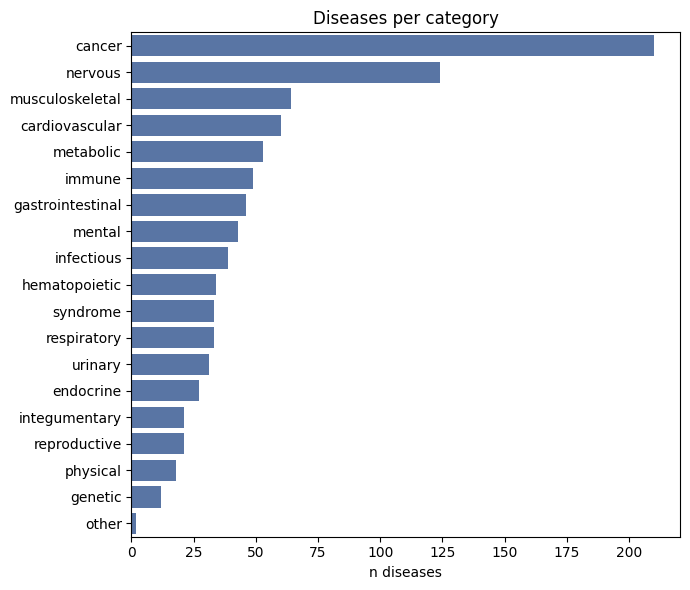

category
cancer              210
nervous             124
musculoskeletal      64
cardiovascular       60
metabolic            53
immune               49
gastrointestinal     46
mental               43
infectious           39
hematopoietic        34
syndrome             33
respiratory          33
urinary              31
endocrine            27
integumentary        21
reproductive         21
physical             18
genetic              12
other                 2


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

order = categories["category"].value_counts().index

fig, ax = plt.subplots(figsize=(7, 6))
sns.countplot(data=categories, y="category", order=order, color="#4C72B0", ax=ax)
ax.set(xlabel="n diseases", ylabel="", title="Diseases per category")
plt.tight_layout(); plt.show()

print(categories["category"].value_counts().to_string())

#### Context graph size by category

Does disease category track with the size of the context the model gets to read?

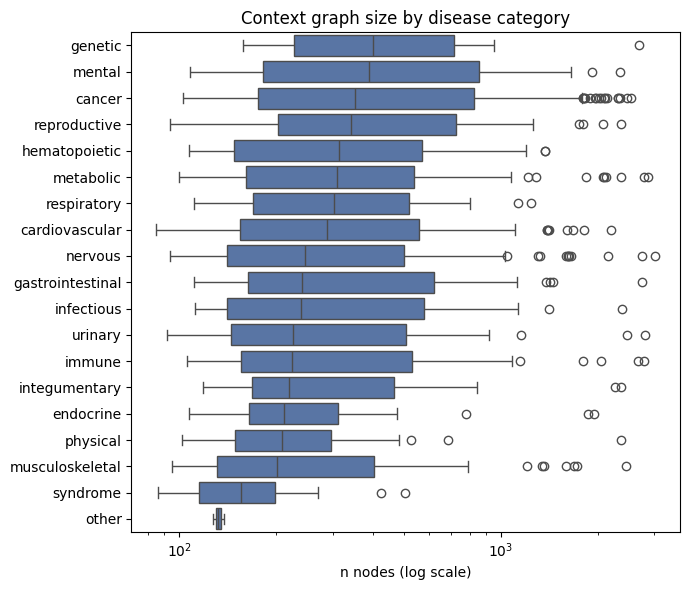

category
genetic             401.0
mental              390.0
cancer              353.0
reproductive        342.0
hematopoietic       315.0
metabolic           309.0
respiratory         304.0
cardiovascular      289.0
nervous             247.0
gastrointestinal    241.5
infectious          240.0
urinary             226.0
immune              224.0
integumentary       220.0
endocrine           212.0
physical            209.5
musculoskeletal     201.5
syndrome            156.0
other               132.5


In [35]:
graph_sizes = pd.DataFrame([
    {"doid": doid,
     "n_nodes": G.number_of_nodes(),
     "n_edges": G.number_of_edges(),
     "n_seed": int(sum(m for _, m in G.nodes(data="m")))}
    for doid, G in context_graphs.items()
]).merge(categories, on="doid")

order = graph_sizes.groupby("category")["n_nodes"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(7, 6))
sns.boxplot(data=graph_sizes, y="category", x="n_nodes", order=order, color="#4C72B0", ax=ax)
ax.set(xscale="log", xlabel="n nodes (log scale)", ylabel="", title="Context graph size by disease category")
plt.tight_layout(); plt.show()

print(graph_sizes.groupby("category")["n_nodes"].median().sort_values(ascending=False).to_string())

Every box spans well over an order of magnitude, so category alone is a weak predictor of how much interactome a disease brings with it. Consistent with what we already saw in the DISEASES section: size is driven mostly by how much has been published about a disease, not by which organ system or disease class it belongs to. The 1-hop expansion does not change that — it scales roughly with the gene set it is grown from.

#### Association confidence by category

Do some categories carry stronger evidence than others?

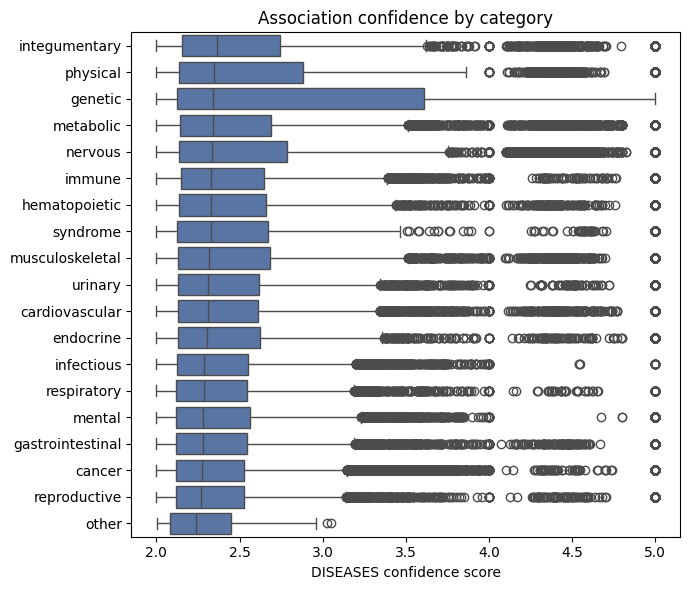

category
integumentary       2.363
physical            2.346
genetic             2.340
metabolic           2.339
nervous             2.337
immune              2.331
hematopoietic       2.329
syndrome            2.328
musculoskeletal     2.319
urinary             2.311
cardiovascular      2.310
endocrine           2.303
infectious          2.288
respiratory         2.285
mental              2.282
gastrointestinal    2.282
cancer              2.275
reproductive        2.270
other               2.238


In [36]:
conf_by_cat = diseases[["doid", "conf"]].merge(categories[["doid", "category"]], on="doid")

order = conf_by_cat.groupby("category")["conf"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(7, 6))
sns.boxplot(data=conf_by_cat, y="category", x="conf", order=order, color="#4C72B0", ax=ax)
ax.set(xlabel="DISEASES confidence score", ylabel="", title="Association confidence by category")
plt.tight_layout(); plt.show()

print(conf_by_cat.groupby("category")["conf"].median().sort_values(ascending=False).to_string())

Median confidence barely moves across categories (roughly 2.2-2.4 out of the 0-5 scale) — evidence
quality is fairly uniform once the 2.0 floor has already been applied, so unlike network size,
confidence is not a useful category signal on its own.

#### The largest context graph in each category

A concrete anchor for what "large" means per category — the single biggest context graph in each of the 19.

In [37]:
biggest_per_category = graph_sizes.loc[graph_sizes.groupby("category")["n_nodes"].idxmax()]
biggest_per_category = biggest_per_category.sort_values("n_nodes", ascending=False)
print(biggest_per_category[["category", "doid_name", "n_nodes", "n_edges", "n_seed"]].to_string(index=False))

        category                          doid_name  n_nodes  n_edges  n_seed
         nervous             Sensory system disease     3015    41280    1747
       metabolic         Glucose metabolism disease     2860    45013    1836
         urinary             Urinary system disease     2799    45057    1773
          immune   Primary immunodeficiency disease     2786    43333    1846
gastrointestinal                      Liver disease     2747    46656    1768
         genetic        Autosomal recessive disease     2683    36196    1573
          cancer          Respiratory system cancer     2544    44279    1582
 musculoskeletal                       Bone disease     2448    38619    1546
      infectious           Viral infectious disease     2384    38184    1493
        physical                  Physical disorder     2371    28678    1350
   integumentary       Integumentary system disease     2364    36795    1448
    reproductive Female reproductive system disease     2355    

## FiLM-conditioned GNN on the masked interactome

### Training

Three objectives, and no disease category among them:

- **$\mathcal{L}_\text{edge}$** — hold out 15% of each context graph's interactions and predict them back from the node states, against an equal number of sampled non-edges (binary cross-entropy).
- **$\mathcal{L}_\text{context}$** — a disease-context contrastive loss: disease genes should end up looking different from the *local background* around them.
- **$\mathcal{L}_\text{anti-collapse}$** — the variance/covariance pair from the disease-graph demo, penalising output dimensions that collapse to a constant or duplicate each other.

The mask is the thing $\mathcal{L}_\text{context}$ has to be built around, because the mask is an *input*: $m_i$ reaches every layer through FiLM, so "predict $m_i$ from $h_i$" is free and teaches the model nothing at all. The fix is the one already used for edges — hide it, then ask for it back. At every step a random `HIDE_FRAC` of nodes have their $(m_i, c_i)$ zeroed *before* the encoder sees them, which makes a hidden disease gene indistinguishable, in its own features, from a background protein. The contrastive loss is computed on exactly those nodes, so the only thing left to separate them is the network context around them.

That also gives the objective a meaning outside training: a protein the model has never been told anything about gets scored by where it sits in the interactome relative to the disease, which is the question the whole "mask the interactome" framing is asking. Disease categories are still loaded below, but only to build a train/val split — never as a training signal.

#### Setup

In [38]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
import torch_geometric.transforms as T
from torch_geometric.nn import GCNConv, global_add_pool
from torch_geometric.utils import scatter

from gea.gea import set_seed

DATA_DIR = Path("data/diseases")
OUT_DIR = Path("data/mask-the-interactome")
SEED = 42
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(OUT_DIR / "context_graphs.pkl", "rb") as f:
    context_graphs = pickle.load(f)
categories = pd.read_csv(DATA_DIR / "disease_categories.tsv", sep="\t")
category_by_doid = categories.set_index("doid")["category"]

print(f"device: {device}")
print(f"{len(context_graphs):,} context graphs loaded")

device: cuda
920 context graphs loaded


### From networkx to PyTorch Geometric

Each graph's node feature stays `[m, c, esm_embedding]`, with one change: the raw ESM-2 embeddings are **whitened** first. Real ESM-2 vectors for this protein set are extremely anisotropic — almost every pair has cosine similarity ≈ 0.98 — so a model reading them directly is barely told apart one protein from another. `compress_embeddings_pca` rescales the space so directions that actually differ between proteins count as much as the ones that don't, down to the specified dimensions.

Edges become bidirectional (`GCNConv` expects a directed edge list, so an undirected interaction needs both directions) with `edge_attr = combined_score / 1000`, matching the 0-1 confidence convention used throughout. The two conditioning channels are kept as columns 0 and 1 of `x`, which is all the model needs to split identity from disease state.

In [39]:
from gea.utils import compress_embeddings_pca

esm_reduced_dim = 512

protein_to_esm_raw = {}
for G in context_graphs.values():
    for p in G.nodes:
        if p not in protein_to_esm_raw:
            protein_to_esm_raw[p] = G.nodes[p]["x"][2:]

proteins_ordered = list(protein_to_esm_raw.keys())
esm_raw = torch.stack([protein_to_esm_raw[p] for p in proteins_ordered]).float()
esm_whitened = compress_embeddings_pca(esm_raw, n_components=esm_reduced_dim, whiten=True)
protein_to_esm_white = dict(zip(proteins_ordered, esm_whitened))


def to_pyg(doid, G):
    nodes = sorted(G.nodes())
    idx = {n: i for i, n in enumerate(nodes)}
    cond = torch.stack([G.nodes[n]["x"][:2] for n in nodes]).float()  # [mask, confidence / 5]
    esm = torch.stack([protein_to_esm_white[n] for n in nodes]).float()
    x = torch.cat([cond, esm], dim=1)

    edges = list(G.edges(data="combined_score"))
    src = [idx[u] for u, v, _ in edges] + [idx[v] for u, v, _ in edges]
    dst = [idx[v] for u, v, _ in edges] + [idx[u] for u, v, _ in edges]
    weight = [s / 1000.0 for _, _, s in edges] * 2

    edge_index = torch.tensor([src, dst], dtype=torch.long)
    edge_attr = torch.tensor(weight, dtype=torch.float).view(-1, 1)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, doid=doid)


pyg_graphs = {doid: to_pyg(doid, G) for doid, G in context_graphs.items()}
example = next(iter(pyg_graphs.values()))
masked_frac = np.mean([float(d.x[:, 0].mean()) for d in pyg_graphs.values()])
print(f"{len(pyg_graphs):,} PyG graphs built | node feature dim {example.x.shape[1]} "
      f"(mask + confidence + {esm_reduced_dim} whitened ESM)")
print(f"mean masked fraction per graph: {masked_frac:.2f}")

PCA: 1280→512 dims, 95.7% variance retained.
920 PyG graphs built | node feature dim 514 (mask + confidence + 512 whitened ESM)
mean masked fraction per graph: 0.49


#### Held-out diseases, not just held-out edges

We split at the disease level first (90/10, stratified by category so both splits look similar) so
validation measures generalisation to diseases the encoder has never seen at all — a much harder and
more honest test than only hiding a few edges inside diseases it already trained on.

In [40]:
all_doids = list(pyg_graphs.keys())
train_doids, val_doids = train_test_split(
    all_doids, test_size=0.2, random_state=SEED,
    stratify=[category_by_doid[d] for d in all_doids],
)
print(f"{len(train_doids):,} train diseases | {len(val_doids):,} val diseases")

736 train diseases | 184 val diseases


#### Held-out edges within each graph

Within every context graph, `RandomLinkSplit` hides 15% of its interactions from message passing and pairs them with an equal number of sampled non-edges. The encoder only ever sees the remaining 85% (`edge_index`); the held-out set (`edge_label_index` / `edge_label`) is what actually tests whether it recovers structure it wasn't shown, rather than memorising the edges it was trained on. Held-out edges are drawn from the whole context graph, background included — the model is predicting the interactome, not just the disease's own corner of it.

In [41]:
MIN_EDGES = 20  # RandomLinkSplit needs enough edges left to make a sensible held-out set

link_splitter = T.RandomLinkSplit(
    num_val=0.0, num_test=0.15, is_undirected=True,
    add_negative_train_samples=True, neg_sampling_ratio=1.0,
)


def split_edges(doids):
    message, held_out, dropped = [], [], 0
    for doid in doids:
        data = pyg_graphs[doid]
        if data.num_edges < MIN_EDGES:
            dropped += 1
            continue
        train_data, _, test_data = link_splitter(data)
        message.append(train_data)
        held_out.append(test_data)
    return message, held_out, dropped


train_msg, train_eval, n_dropped_train = split_edges(train_doids)
val_msg, val_eval, n_dropped_val = split_edges(val_doids)

print(f"train: {len(train_msg):,} graphs ({n_dropped_train} dropped, < {MIN_EDGES} edges)")
print(f"val:   {len(val_msg):,} graphs ({n_dropped_val} dropped, < {MIN_EDGES} edges)")

train: 736 graphs (0 dropped, < 20 edges)
val:   184 graphs (0 dropped, < 20 edges)


### The model

Encoder: a 3-layer GCN with residual connections — a few rounds of neighbourhood averaging erode a node's own identity, so each layer adds its update on top of the previous representation instead of replacing it — and **FiLM conditioning** after every layer. A small network $f_\theta$ maps each node's disease state to a per-dimension scale and shift,

$$\gamma_i^{(l)}, \beta_i^{(l)} = f_\theta(m_i^{(d)}, c_i^{(d)}), \qquad h_i^{(l)} \leftarrow \gamma_i^{(l)} \odot h_i^{(l)} + \beta_i^{(l)}$$

so the same protein in the same interactome is modulated differently depending on which disease it is being read for, at every depth rather than only at the input. $f_\theta$'s output layer is zero-initialised, so training starts from $\gamma = 1, \beta = 0$ — a plain residual GCN — and the conditioning is something the model has to earn.

Two heads:

- **edge decoder** — an MLP over $[h_i \odot h_j, |h_i - h_j|]$, replacing the plain dot product: it can score a pair on agreement *and* on distance rather than agreement alone.
- **context head** — a linear projection into a smaller space where the contrastive loss lives. Each graph gets a prototype $p_d$, the mean projection of its still-*visible* disease genes, and a node's context score is its cosine similarity to that prototype.

In [42]:
h_dim = esm_reduced_dim  # hidden dim for GCN layers
z_dim = 128
proj_dim = 64            # context head


class FiLM(nn.Module):
    """Per-node feature-wise modulation conditioned on the disease state (m, c)."""

    def __init__(self, hidden_dim, cond_dim=2, film_hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cond_dim, film_hidden),
            nn.ReLU(),
            nn.Linear(film_hidden, 2 * hidden_dim),
        )
        nn.init.zeros_(self.net[-1].weight)  # start at gamma = 1, beta = 0 (plain residual GCN)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, h, cond):
        gamma, beta = self.net(cond).chunk(2, dim=-1)
        return (1.0 + gamma) * h + beta


class MaskedInteractomeGNN(nn.Module):
    def __init__(self, esm_dim, hidden_dim=h_dim, out_dim=z_dim, n_layers=3, dropout=0.2):
        super().__init__()
        self.proj = nn.Linear(esm_dim + 2, hidden_dim)
        self.convs = nn.ModuleList([GCNConv(hidden_dim, hidden_dim) for _ in range(n_layers)])
        self.films = nn.ModuleList([FiLM(hidden_dim) for _ in range(n_layers)])
        self.out_proj = nn.Linear(hidden_dim, out_dim)
        self.dropout = dropout

        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * out_dim, out_dim), nn.ReLU(), nn.Linear(out_dim, 1)
        )
        self.context_head = nn.Linear(out_dim, proj_dim)

    def encode(self, x, edge_index, edge_weight, hide=None):
        """`hide` zeroes (m, c) for the given nodes, everywhere they would otherwise be read."""
        cond = x[:, :2]
        if hide is not None:
            cond = cond.masked_fill(hide.unsqueeze(-1), 0.0)

        h = self.proj(torch.cat([cond, x[:, 2:]], dim=1))
        for conv, film in zip(self.convs, self.films):
            h = h + F.relu(conv(h, edge_index, edge_weight))
            h = film(h, cond)
            h = F.dropout(h, p=self.dropout, training=self.training)
        return self.out_proj(h)

    def decode_edges(self, h, edge_label_index):
        src, dst = edge_label_index
        pair = torch.cat([h[src] * h[dst], (h[src] - h[dst]).abs()], dim=-1)
        return self.edge_mlp(pair).squeeze(-1)

    def context_scores(self, h, mask, hide, batch, num_graphs):
        """Cosine similarity of every node to its own graph's visible-disease-gene prototype."""
        z = F.normalize(self.context_head(h), dim=-1)
        visible = ((mask > 0.5) & ~hide).float().unsqueeze(-1)
        total = global_add_pool(z * visible, batch, size=num_graphs)
        count = global_add_pool(visible, batch, size=num_graphs).clamp(min=1.0)
        prototype = F.normalize(total / count, dim=-1)
        return (z * prototype[batch]).sum(dim=-1)


esm_dim = example.x.shape[1] - 2  # x = [mask, confidence, esm_embedding]
model = MaskedInteractomeGNN(esm_dim).to(device)
print(model)
print(f"\n{sum(p.numel() for p in model.parameters()):,} parameters")

MaskedInteractomeGNN(
  (proj): Linear(in_features=514, out_features=512, bias=True)
  (convs): ModuleList(
    (0-2): 3 x GCNConv(512, 512)
  )
  (films): ModuleList(
    (0-2): 3 x FiLM(
      (net): Sequential(
        (0): Linear(in_features=2, out_features=32, bias=True)
        (1): ReLU()
        (2): Linear(in_features=32, out_features=1024, bias=True)
      )
    )
  )
  (out_proj): Linear(in_features=512, out_features=128, bias=True)
  (edge_mlp): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
  (context_head): Linear(in_features=128, out_features=64, bias=True)
)

1,260,257 parameters


#### Training

$\mathcal{L} = \mathcal{L}_\text{edge} + \mathcal{L}_\text{context} + \lambda_\text{var}\mathcal{L}_\text{var} + \lambda_\text{cov}\mathcal{L}_\text{cov}$.

$\mathcal{L}_\text{context}$ is InfoNCE with the disease prototype as the query: within each graph the hidden disease genes are the positives and the hidden background proteins are the negatives, so a positive only scores well if it lands closer to the disease prototype than the background proteins around it do. Both classes are hidden, and a hidden disease gene looks exactly like a background protein from its own features, so the separation has to come from the neighbourhood.

Neither main objective actually requires the encoder to spread information across all 128 output dimensions on its own — the **variance** term penalises any dimension whose spread across the batch collapses towards zero, and the **covariance** term penalises dimensions that duplicate each other.

In [43]:
EPOCHS = 100
BATCH_SIZE = 16
HIDE_FRAC = 0.15        # fraction of nodes whose (m, c) is hidden from the encoder
CONTEXT_TAU = 0.1       # InfoNCE temperature
CONTEXT_WEIGHT = 1.0
VAR_WEIGHT = 1.0
COV_WEIGHT = 0.05


def variance_covariance_loss(z, eps=1e-4):
    """Penalise collapsed (near-zero variance) or duplicated (correlated) output dimensions."""
    z = z - z.mean(dim=0, keepdim=True)
    std = torch.sqrt(z.var(dim=0, unbiased=False) + eps)
    var_loss = torch.relu(1.0 - std).mean()

    n, d = z.shape
    cov = (z.T @ z) / (n - 1)
    off_diag = cov.flatten()[1:].view(d - 1, d + 1)[:, :-1].flatten()
    cov_loss = off_diag.pow(2).sum() / d
    return var_loss, cov_loss


def context_loss(scores, mask, hide, batch, num_graphs, tau=CONTEXT_TAU):
    """InfoNCE per graph: hidden disease genes as positives, hidden background as negatives."""
    s = scores / tau
    pos = hide & (mask > 0.5)
    neg = hide & (mask <= 0.5)
    if not pos.any() or not neg.any():
        return scores.new_zeros(())

    b_neg, s_neg = batch[neg], s[neg]
    max_neg = scatter(s_neg, b_neg, dim=0, dim_size=num_graphs, reduce="max")
    lse_neg = max_neg + torch.log(
        scatter(torch.exp(s_neg - max_neg[b_neg]), b_neg, dim=0, dim_size=num_graphs, reduce="sum") + 1e-12
    )
    has_neg = scatter(torch.ones_like(s_neg), b_neg, dim=0, dim_size=num_graphs, reduce="sum") > 0

    b_pos, s_pos = batch[pos], s[pos]
    keep = has_neg[b_pos]
    if not keep.any():
        return scores.new_zeros(())
    b_pos, s_pos = b_pos[keep], s_pos[keep]

    # -log( exp(s_i) / (exp(s_i) + sum_j exp(s_j)) ), averaged within a graph then across graphs
    per_node = -(s_pos - torch.logaddexp(s_pos, lse_neg[b_pos]))
    per_graph = scatter(per_node, b_pos, dim=0, dim_size=num_graphs, reduce="mean")
    scored = scatter(torch.ones_like(per_node), b_pos, dim=0, dim_size=num_graphs, reduce="sum") > 0
    return per_graph[scored].mean()


# the validation hide-sets are drawn once, so every evaluation asks the same question
hide_generator = torch.Generator().manual_seed(SEED)
val_hide = [torch.rand(data.num_nodes, generator=hide_generator) < HIDE_FRAC for data in val_msg]


@torch.no_grad()
def evaluate(model, msg_list, eval_list, hide_list):
    model.eval()
    context_aucs, edge_aucs = [], []
    for msg, held_out, hide in zip(msg_list, eval_list, hide_list):
        x = msg.x.to(device)
        edge_index = msg.edge_index.to(device)
        edge_weight = msg.edge_attr.squeeze(-1).to(device)

        # edges are scored with the full disease state — the way the model is meant to be used
        h = model.encode(x, edge_index, edge_weight)
        logits = model.decode_edges(h, held_out.edge_label_index.to(device))
        y_edge = held_out.edge_label.numpy()
        if len(set(y_edge)) > 1:
            edge_aucs.append(roc_auc_score(y_edge, logits.sigmoid().cpu().numpy()))

        # context is scored with the hidden nodes' own (m, c) zeroed, exactly as in training
        hidden = hide.to(device)
        h_hidden = model.encode(x, edge_index, edge_weight, hide=hidden)
        single = torch.zeros(msg.num_nodes, dtype=torch.long, device=device)
        scores = model.context_scores(h_hidden, x[:, 0], hidden, single, 1)
        y_context = (msg.x[:, 0] > 0.5)[hide].numpy()
        if len(set(y_context)) > 1:
            context_aucs.append(roc_auc_score(y_context, scores[hidden].cpu().numpy()))

    return float(np.mean(context_aucs)), float(np.mean(edge_aucs))


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
train_loader = DataLoader(train_msg, batch_size=BATCH_SIZE, shuffle=True)

history = []
for epoch in range(EPOCHS):
    model.train()
    total_loss = total_edge = total_context = total_var = total_cov = 0.0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        hide = torch.rand(batch.num_nodes, device=device) < HIDE_FRAC
        h = model.encode(batch.x, batch.edge_index, batch.edge_attr.squeeze(-1), hide=hide)

        edge_logits = model.decode_edges(h, batch.edge_label_index)
        edge_loss = F.binary_cross_entropy_with_logits(edge_logits, batch.edge_label)

        scores = model.context_scores(h, batch.x[:, 0], hide, batch.batch, batch.num_graphs)
        ctx_loss = context_loss(scores, batch.x[:, 0], hide, batch.batch, batch.num_graphs)

        var_loss, cov_loss = variance_covariance_loss(h)

        loss = (edge_loss + CONTEXT_WEIGHT * ctx_loss
                + VAR_WEIGHT * var_loss + COV_WEIGHT * cov_loss)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs
        total_edge += edge_loss.item() * batch.num_graphs
        total_context += ctx_loss.item() * batch.num_graphs
        total_var += var_loss.item() * batch.num_graphs
        total_cov += cov_loss.item() * batch.num_graphs

    train_loss = total_loss / len(train_msg)
    if epoch % 10 == 0 or epoch == EPOCHS - 1:
        val_context_auc, val_edge_auc = evaluate(model, val_msg, val_eval, val_hide)
        history.append({
            "epoch": epoch, "train_loss": train_loss,
            "edge_loss": total_edge / len(train_msg), "context_loss": total_context / len(train_msg),
            "var_loss": total_var / len(train_msg), "cov_loss": total_cov / len(train_msg),
            "val_context_auc": val_context_auc, "val_edge_auc": val_edge_auc,
        })
        print(f"epoch {epoch:3d} | train loss {train_loss:.4f} | "
              f"val context AUC {val_context_auc:.4f} | val edge AUC {val_edge_auc:.4f}")

/home/s243564/miniforge3/envs/gea/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


epoch   0 | train loss 4.0333 | val context AUC 0.8287 | val edge AUC 0.7478


/home/s243564/miniforge3/envs/gea/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


epoch  10 | train loss 2.7454 | val context AUC 0.8770 | val edge AUC 0.8698


/home/s243564/miniforge3/envs/gea/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


...

epoch  80 | train loss 1.4758 | val context AUC 0.9240 | val edge AUC 0.9303


/home/s243564/miniforge3/envs/gea/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


epoch  90 | train loss 1.4470 | val context AUC 0.9256 | val edge AUC 0.9293


/home/s243564/miniforge3/envs/gea/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


epoch  99 | train loss 1.3857 | val context AUC 0.9308 | val edge AUC 0.9333


#### Is the model learning anything beyond the obvious?

One baseline per objective, both of them free of any learned embedding at all.

**Edges** — the **degree product**: score a candidate pair by how many message-passing edges each endpoint has. Hub proteins interact with everything, so a model that has only learned "hubs interact" would already score well here, and the "network matters" story would rest on nothing more than that.

**Context** — the **visible-seed neighbour vote**: score a hidden node by the fraction of its STRING partners that are still-visible disease genes. This is the whole of guilt-by-association in a single number, and it is exactly the shortcut a message-passing model can settle for. Clearing it means the encoder is using more of the context than a one-hop vote.

In [44]:
final_context_auc, final_edge_auc = evaluate(model, val_msg, val_eval, val_hide)

# degree-product baseline for edge prediction — no learned embedding, just message-passing degree
degree_aucs = []
for msg, held_out in zip(val_msg, val_eval):
    degree = np.bincount(msg.edge_index[0].numpy(), minlength=msg.num_nodes)
    src, dst = held_out.edge_label_index.numpy()
    scores = degree[src] * degree[dst]
    y = held_out.edge_label.numpy()
    if len(set(y)) > 1:
        degree_aucs.append(roc_auc_score(y, scores))
degree_auc = float(np.mean(degree_aucs))

# neighbour-vote baseline for the context objective — the fraction of a hidden node's partners
# that are still-visible disease genes, read straight off the adjacency
neighbour_aucs = []
for msg, hide in zip(val_msg, val_hide):
    visible_seed = ((msg.x[:, 0] > 0.5) & ~hide).float()
    src, dst = msg.edge_index
    vote = scatter(visible_seed[src], dst, dim=0, dim_size=msg.num_nodes, reduce="mean")
    y = (msg.x[:, 0] > 0.5)[hide].numpy()
    if len(set(y)) > 1:
        neighbour_aucs.append(roc_auc_score(y, vote[hide].numpy()))
neighbour_auc = float(np.mean(neighbour_aucs))

print(f"{'':26s}{'context AUC':>14s}{'edge AUC':>12s}")
print(f"{'neighbour vote / degree':26s}{neighbour_auc:14.4f}{degree_auc:12.4f}")
print(f"{'trained model':26s}{final_context_auc:14.4f}{final_edge_auc:12.4f}")

                             context AUC    edge AUC
neighbour vote / degree           0.5426      0.8043
trained model                     0.9308      0.9333


Both numbers are held out twice over: the diseases are ones the encoder never trained on, and within them the edges were hidden from message passing and the nodes' disease state hidden from the encoder.

What to read into them. The **context AUC** is the one worth the most scrutiny, because it is the objective whose honesty had to be engineered: a node's own mask is zeroed before the encoder sees it, so the score can only come from the neighbourhood, and the neighbour-vote baseline says how much of that neighbourhood a single one-hop tally already explains. A margin over it is the encoder using the wider context — who the neighbours *are*, not just how many of them are flagged. No margin would mean the FiLM conditioning is buying nothing that guilt-by-association did not already provide. The **edge AUC** is the more conventional of the two, and mostly guards against the representation collapsing: the sanity check in the Evaluation section below confirms the embedding space is actually being used before trusting any picture drawn from it.

#### Saving trained model

In [45]:
CHECKPOINT_FILE = OUT_DIR / "mask_gnn.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "history": history,
    "val_context_auc": final_context_auc,
    "val_edge_auc": final_edge_auc,
    "val_neighbour_auc": neighbour_auc,
    "val_degree_auc": degree_auc,
    "train_doids": train_doids,
    "val_doids": val_doids,
    "hide_frac": HIDE_FRAC,
}, CHECKPOINT_FILE)

print(f"Saved checkpoint to {CHECKPOINT_FILE}")

Saved checkpoint to data/mask-the-interactome/mask_gnn.pt


### Evaluation

#### Training curves

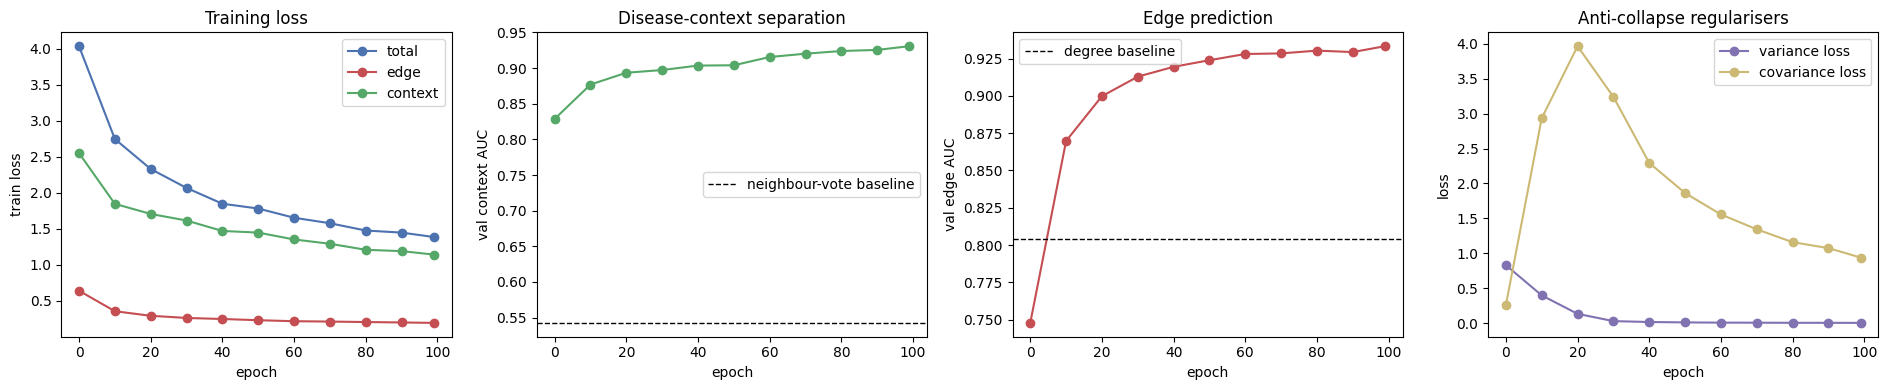

In [46]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 4, figsize=(19, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", color="#4C72B0", label="total")
axes[0].plot(history_df["epoch"], history_df["edge_loss"], marker="o", color="#C44E52", label="edge")
axes[0].plot(history_df["epoch"], history_df["context_loss"], marker="o", color="#55A868", label="context")
axes[0].set(xlabel="epoch", ylabel="train loss", title="Training loss")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["val_context_auc"], marker="o", color="#55A868")
axes[1].axhline(neighbour_auc, color="k", ls="--", lw=1, label="neighbour-vote baseline")
axes[1].set(xlabel="epoch", ylabel="val context AUC", title="Disease-context separation")
axes[1].legend()

axes[2].plot(history_df["epoch"], history_df["val_edge_auc"], marker="o", color="#C44E52")
axes[2].axhline(degree_auc, color="k", ls="--", lw=1, label="degree baseline")
axes[2].set(xlabel="epoch", ylabel="val edge AUC", title="Edge prediction")
axes[2].legend()

axes[3].plot(history_df["epoch"], history_df["var_loss"], marker="o", color="#8172B2", label="variance loss")
axes[3].plot(history_df["epoch"], history_df["cov_loss"], marker="o", color="#CCB974", label="covariance loss")
axes[3].set(xlabel="epoch", ylabel="loss", title="Anti-collapse regularisers")
axes[3].legend()

plt.tight_layout(); plt.show()

#### Held-out edge prediction: model vs. degree baseline

The AUC numbers reported earlier are averaged one-graph-at-a-time. Pooling every held-out edge and non-edge across all validation diseases into a single ROC curve shows the same comparison directly.

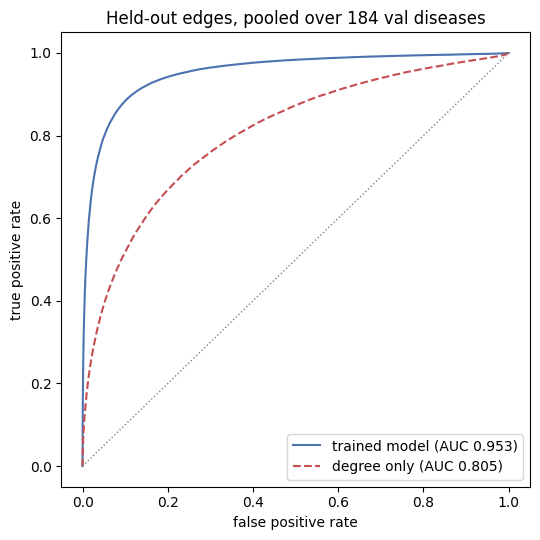

In [47]:
from sklearn.metrics import roc_curve

model.eval()
all_y, all_model_scores, all_degree_scores = [], [], []
with torch.no_grad():
    for msg, held_out in zip(val_msg, val_eval):
        h = model.encode(msg.x.to(device), msg.edge_index.to(device), msg.edge_attr.squeeze(-1).to(device))
        logits = model.decode_edges(h, held_out.edge_label_index.to(device)).sigmoid().cpu().numpy()

        degree = np.bincount(msg.edge_index[0].numpy(), minlength=msg.num_nodes)
        src, dst = held_out.edge_label_index.numpy()

        all_y.append(held_out.edge_label.numpy())
        all_model_scores.append(logits)
        all_degree_scores.append(degree[src] * degree[dst])

y_all = np.concatenate(all_y)
model_scores = np.concatenate(all_model_scores)
degree_scores = np.concatenate(all_degree_scores)

pooled_model_auc = roc_auc_score(y_all, model_scores)
pooled_degree_auc = roc_auc_score(y_all, degree_scores)

fpr_m, tpr_m, _ = roc_curve(y_all, model_scores)
fpr_d, tpr_d, _ = roc_curve(y_all, degree_scores)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot(fpr_m, tpr_m, color="#4C72B0", label=f"trained model (AUC {pooled_model_auc:.3f})")
ax.plot(fpr_d, tpr_d, color="#C44E52", ls="--", label=f"degree only (AUC {pooled_degree_auc:.3f})")
ax.plot([0, 1], [0, 1], color="grey", lw=1, ls=":")
ax.set(xlabel="false positive rate", ylabel="true positive rate",
       title=f"Held-out edges, pooled over {len(val_msg)} val diseases")
ax.legend()
plt.tight_layout(); plt.show()

#### Does performance vary by disease size?

A single mean AUC can hide a lot: maybe the model is great on large, well-connected contexts and close to chance on small ones. Breaking both objectives down per validation disease, and against context graph size, checks that directly.

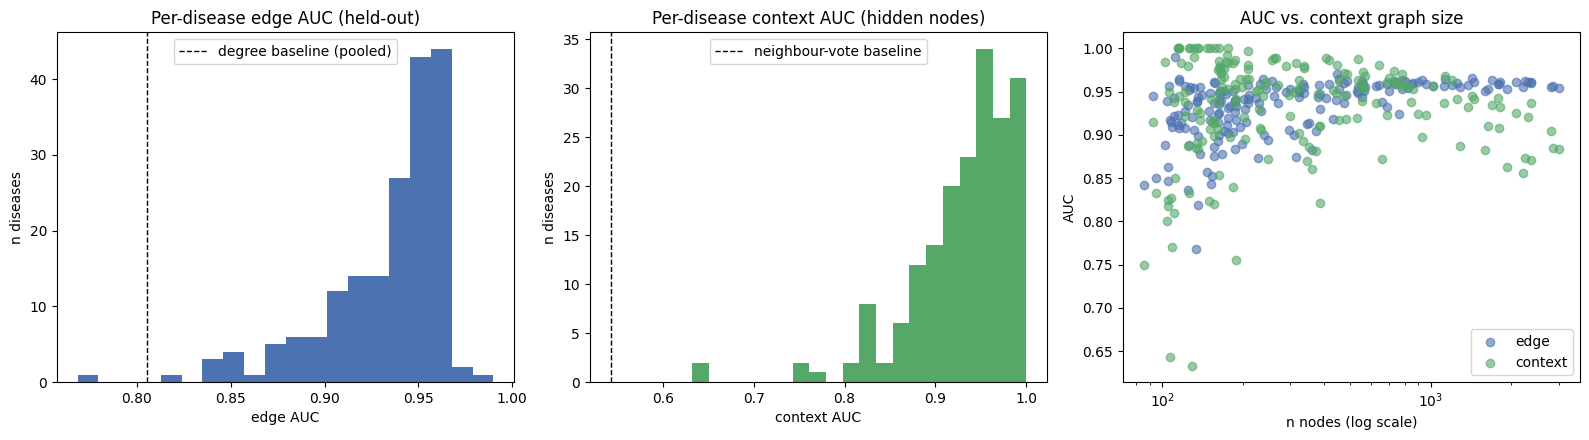

corr(n_nodes, edge AUC)    = 0.392
corr(n_nodes, context AUC) = -0.076
         edge_auc  context_auc
count  184.000000   184.000000
mean     0.933284     0.930817
std      0.033467     0.060245
min      0.768430     0.632653
25%      0.916720     0.906250
50%      0.944432     0.945369
75%      0.957060     0.971909
max      0.990001     1.000000


In [48]:
per_disease = []
model.eval()
with torch.no_grad():
    for msg, held_out, hide in zip(val_msg, val_eval, val_hide):
        x = msg.x.to(device)
        edge_index = msg.edge_index.to(device)
        edge_weight = msg.edge_attr.squeeze(-1).to(device)

        h = model.encode(x, edge_index, edge_weight)
        logits = model.decode_edges(h, held_out.edge_label_index.to(device)).sigmoid().cpu().numpy()
        y = held_out.edge_label.numpy()

        hidden = hide.to(device)
        h_hidden = model.encode(x, edge_index, edge_weight, hide=hidden)
        single = torch.zeros(msg.num_nodes, dtype=torch.long, device=device)
        scores = model.context_scores(h_hidden, x[:, 0], hidden, single, 1)[hidden].cpu().numpy()
        y_context = (msg.x[:, 0] > 0.5)[hide].numpy()

        if len(set(y)) > 1 and len(set(y_context)) > 1:
            per_disease.append({
                "doid": msg.doid, "n_nodes": msg.num_nodes,
                "edge_auc": roc_auc_score(y, logits),
                "context_auc": roc_auc_score(y_context, scores),
            })

per_disease = pd.DataFrame(per_disease)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(per_disease["edge_auc"], bins=20, color="#4C72B0")
axes[0].axvline(pooled_degree_auc, color="k", ls="--", lw=1, label="degree baseline (pooled)")
axes[0].set(xlabel="edge AUC", ylabel="n diseases", title="Per-disease edge AUC (held-out)")
axes[0].legend()

axes[1].hist(per_disease["context_auc"], bins=20, color="#55A868")
axes[1].axvline(neighbour_auc, color="k", ls="--", lw=1, label="neighbour-vote baseline")
axes[1].set(xlabel="context AUC", ylabel="n diseases", title="Per-disease context AUC (hidden nodes)")
axes[1].legend()

axes[2].scatter(per_disease["n_nodes"], per_disease["edge_auc"], alpha=0.6, color="#4C72B0", label="edge")
axes[2].scatter(per_disease["n_nodes"], per_disease["context_auc"], alpha=0.6, color="#55A868", label="context")
axes[2].set(xscale="log", xlabel="n nodes (log scale)", ylabel="AUC", title="AUC vs. context graph size")
axes[2].legend()

plt.tight_layout(); plt.show()

print(f"corr(n_nodes, edge AUC)    = {per_disease['n_nodes'].corr(per_disease['edge_auc']):.3f}")
print(f"corr(n_nodes, context AUC) = {per_disease['n_nodes'].corr(per_disease['context_auc']):.3f}")
print(per_disease[["edge_auc", "context_auc"]].describe())

#### Extracting node, edge and graph embeddings

For everything below we re-encode every disease using its **full** context graph — all edges, nothing hidden, the complete disease state — since these embeddings are meant for downstream analysis rather than for testing held-out generalisation. One forward pass per disease gives the node states $h_i^{(d)}$, and the three levels are read off them:

- **node** — $h_i^{(d)}$ itself, one row per (disease, protein), local background included.
- **edge** — $e_{ij}^{(d)} = \dfrac{h_i^{(d)} \odot h_j^{(d)}}{\lVert h_i^{(d)} - h_j^{(d)} \rVert_2}$: how much the two endpoints agree, divided by how far apart they are. L2 rather than L1 in the denominator, because after PCA-whitening the coordinate axes carry no meaning of their own and an L1 norm would make the embedding depend on that arbitrary basis. Keeping it a ratio instead of the concatenation $[h_i \odot h_j, |h_i - h_j|]$ the edge decoder scores with also keeps every level at the same 128 dimensions, so the three SAEs below are directly comparable. A ratio does need a guard, though: two endpoints landing on top of each other would send a row off to infinity and let it dominate everything trained on top of it, so the denominator is clamped at a low quantile of the distances the model actually produces rather than at an arbitrary constant.
- **graph** — $g_d = g_d^+ - g_d^-$, the confidence-weighted mean over the masked proteins minus the plain mean over the local background:

$$g_d^+ = \frac{\sum_i m_i^{(d)} c_i^{(d)} h_i^{(d)}}{\sum_i m_i^{(d)} c_i^{(d)}}, \qquad g_d^- = \frac{\sum_i (1 - m_i^{(d)}) h_i^{(d)}}{\sum_i (1 - m_i^{(d)})}$$

  A disease is then described by what makes its genes *different* from the interactome immediately around them, rather than by the composition of its gene set alone — which is the failure mode a plain mean-pooled readout falls into, since a mean over node states is a composition statistic by construction.

Only one direction is kept per edge pair, matching the convention `gea.gea.extract_embeddings` already uses for LIONESS graphs.

In [49]:
from gea.gea import ENTITY_SEP, GENE_PAIR_SEP, save_embeddings

def edge_distance_floor(quantile=0.01, n_sample=50):
    """A floor for the edge denominator, read off the distances the model actually produces.

    Dividing by ||h_i - h_j|| is unbounded: two endpoints that land on top of each other would
    produce a row thousands of times longer than a typical one, which then dominates the SAE (and
    overflows float16 on the way to disk). Clamping the denominator at a low quantile of the real
    distance distribution bounds the ratio without picking an arbitrary constant.
    """
    rng = np.random.default_rng(SEED)
    sample = rng.choice(list(pyg_graphs), size=min(n_sample, len(pyg_graphs)), replace=False)

    distances = []
    model.eval()
    with torch.no_grad():
        for doid in sample:
            data = pyg_graphs[doid]
            h = model.encode(
                data.x.to(device), data.edge_index.to(device), data.edge_attr.squeeze(-1).to(device)
            ).cpu()
            src, dst = data.edge_index
            keep = src < dst
            distances.append((h[src[keep]] - h[dst[keep]]).norm(dim=-1).numpy())

    distances = np.concatenate(distances)
    floor = float(np.quantile(distances, quantile))
    print(f"endpoint distance over {len(sample)} graphs: median {np.median(distances):.2f} | "
          f"min {distances.min():.3f} | q{quantile:.0%} {floor:.2f} → denominator floor")
    return floor


EDGE_DIST_FLOOR = edge_distance_floor()


def extract_all_levels():
    graph_emb, graph_entities, graph_doid, graph_category = [], [], [], []
    node_emb, node_entities, node_doid, node_category, node_protein, node_mask = [], [], [], [], [], []
    edge_emb, edge_entities, edge_doid, edge_category, edge_a, edge_b, edge_n_seed = [], [], [], [], [], [], []

    model.eval()
    with torch.no_grad():
        for doid, data in pyg_graphs.items():
            h = model.encode(
                data.x.to(device), data.edge_index.to(device), data.edge_attr.squeeze(-1).to(device)
            ).cpu()
            nodes = sorted(context_graphs[doid].nodes())  # same order used by to_pyg
            category = category_by_doid.get(doid, "other")
            m, c = data.x[:, 0], data.x[:, 1]

            # graph level: masked-minus-background contrast
            w_pos = (m * c).unsqueeze(-1)
            w_neg = (1.0 - m).unsqueeze(-1)
            g_pos = (w_pos * h).sum(0) / w_pos.sum().clamp(min=1e-8)
            g_neg = (w_neg * h).sum(0) / w_neg.sum().clamp(min=1e-8)
            graph_emb.append((g_pos - g_neg).unsqueeze(0).numpy())
            graph_entities.append(doid)
            graph_doid.append(doid)
            graph_category.append(category)

            # node level
            node_emb.append(h.numpy())
            node_entities.extend(f"{doid}{ENTITY_SEP}{p}" for p in nodes)
            node_doid.extend([doid] * len(nodes))
            node_category.extend([category] * len(nodes))
            node_protein.extend(nodes)
            node_mask.append(m.numpy().astype(np.uint8))

            # edge level
            src, dst = data.edge_index[0].numpy(), data.edge_index[1].numpy()
            keep = src < dst  # both directions are stored; keep one copy per pair
            src, dst = src[keep], dst[keep]
            distance = (h[src] - h[dst]).norm(dim=-1, keepdim=True).clamp(min=EDGE_DIST_FLOOR)
            edge_emb.append(((h[src] * h[dst]) / distance).numpy())
            edge_entities.extend(f"{doid}{ENTITY_SEP}{nodes[s]}{GENE_PAIR_SEP}{nodes[d]}" for s, d in zip(src, dst))
            edge_doid.extend([doid] * len(src))
            edge_category.extend([category] * len(src))
            edge_a.extend(nodes[s] for s in src)
            edge_b.extend(nodes[d] for d in dst)
            edge_n_seed.append((m[src] + m[dst]).numpy().astype(np.uint8))

    graph_export = {
        "embeddings": np.concatenate(graph_emb, axis=0).astype(np.float32),
        "entities": np.array(graph_entities, dtype=object),
        "doid": np.array(graph_doid, dtype=object),
        "category": np.array(graph_category, dtype=object),
        "level": np.array("graph"),
    }
    node_export = {
        "embeddings": np.concatenate(node_emb, axis=0).astype(np.float32),
        "entities": np.array(node_entities, dtype=object),
        "doid": np.array(node_doid, dtype=object),
        "category": np.array(node_category, dtype=object),
        "protein": np.array(node_protein, dtype=object),
        "mask": np.concatenate(node_mask),
        "level": np.array("node"),
    }
    edge_export = {
        "embeddings": np.concatenate(edge_emb, axis=0).astype(np.float16),
        "entities": np.array(edge_entities, dtype=object),
        "doid": np.array(edge_doid, dtype=object),
        "category": np.array(edge_category, dtype=object),
        "protein_a": np.array(edge_a, dtype=object),
        "protein_b": np.array(edge_b, dtype=object),
        "n_seed_endpoints": np.concatenate(edge_n_seed),
        "level": np.array("edge"),
    }
    return graph_export, node_export, edge_export


graph_export, node_export, edge_export = extract_all_levels()
print(f"graph: {graph_export['embeddings'].shape}")
print(f"node:  {node_export['embeddings'].shape}  ({node_export['mask'].mean():.1%} masked)")
print(f"edge:  {edge_export['embeddings'].shape}")

# the edge embedding divides by a distance, so it is worth seeing how long its rows actually get
edge_norms = np.linalg.norm(edge_export["embeddings"].astype(np.float32), axis=1)
print("edge row norm: " + " | ".join(
    f"q{int(q * 100)} {np.quantile(edge_norms, q):.2f}" for q in (0.5, 0.9, 0.99, 1.0)))

endpoint distance over 50 graphs: median 11.02 | min 0.025 | q1% 4.01 → denominator floor
graph: (920, 128)
node:  (455120, 128)  (53.6% masked)
edge:  (5796601, 128)
edge row norm: q50 1.05 | q90 1.83 | q99 3.59 | q100 40.58


#### Graph-level embeddings, visualised by category

The encoder never saw disease category — it only ever optimised the node and edge objectives. Colouring
its graph embeddings by category here is a purely post-hoc diagnostic: any clustering by category
would be an emergent property of gene identity + topology, not something trained for directly.

/home/s243564/miniforge3/envs/gea/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


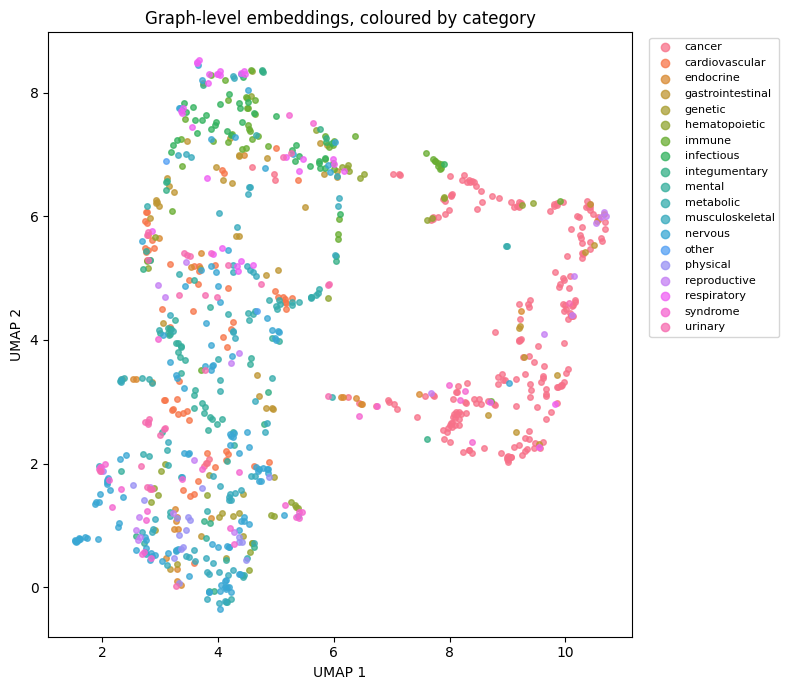

In [50]:
import umap

reducer = umap.UMAP(random_state=SEED)
graph_umap = reducer.fit_transform(graph_export["embeddings"])
graph_categories = graph_export["category"]

cats = sorted(set(graph_categories))
palette = dict(zip(cats, sns.color_palette("husl", len(cats))))

fig, ax = plt.subplots(figsize=(8, 7))
for cat in cats:
    mask = graph_categories == cat
    ax.scatter(graph_umap[mask, 0], graph_umap[mask, 1], s=16, alpha=0.75, color=palette[cat], label=cat)
ax.set(xlabel="UMAP 1", ylabel="UMAP 2", title="Graph-level embeddings, coloured by category")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, markerscale=1.5)
plt.tight_layout(); plt.show()

#### Graph-level embeddings, one panel per category

The single scatter above can only give a handful of categories a distinct colour before it turns into a legend soup. Splitting into one small panel per category — same UMAP layout underneath, just the categories with the most diseases shown first — makes it possible to see whether a Disease Ontology branch actually occupies its own region of the map, or is sprayed across all of it.

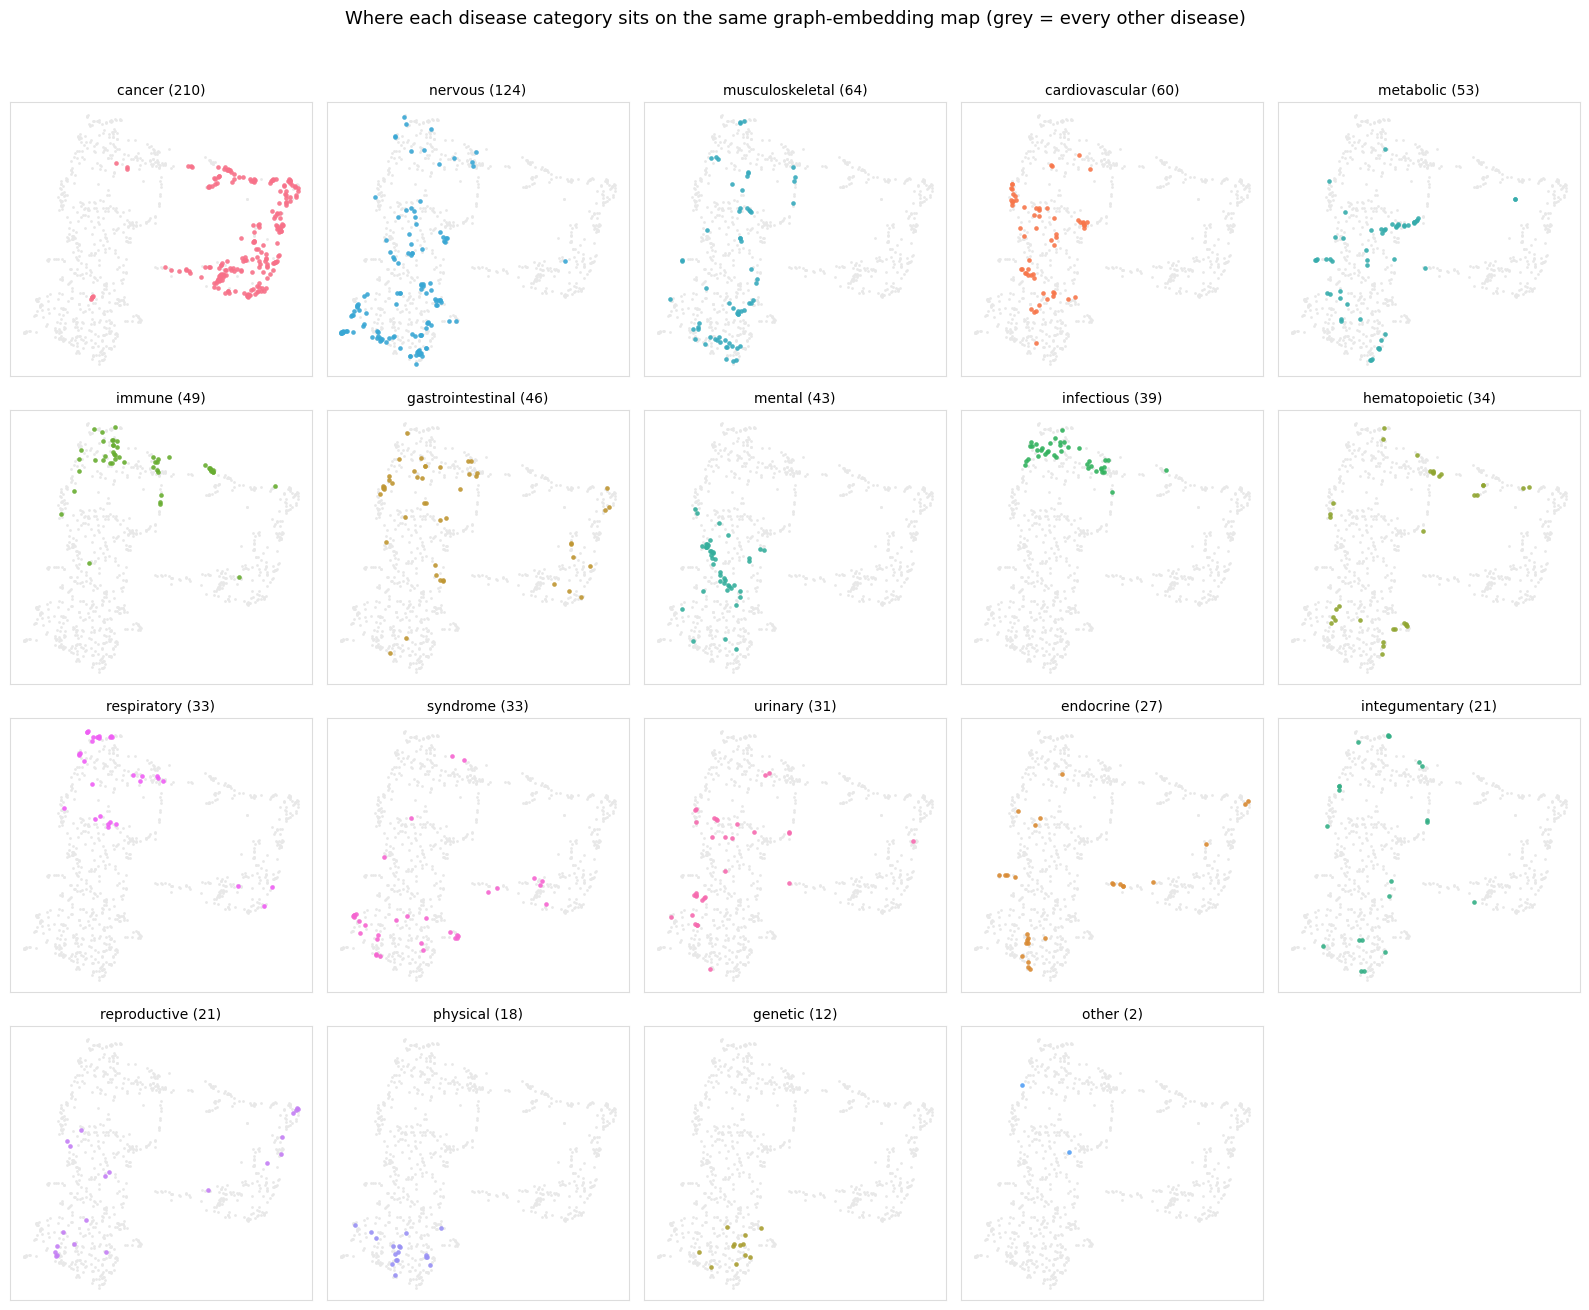

In [51]:
panel_order = sorted(cats, key=lambda c: -(graph_categories == c).sum())
ncol = 5
nrow = int(np.ceil(len(panel_order) / ncol))

fig, axes = plt.subplots(nrow, ncol, figsize=(3.2 * ncol, 3.2 * nrow), sharex=True, sharey=True)
for ax, cat in zip(axes.ravel(), panel_order):
    mask = graph_categories == cat
    ax.scatter(graph_umap[~mask, 0], graph_umap[~mask, 1], s=4, color="#e8e8e8", linewidths=0, zorder=1)
    ax.scatter(graph_umap[mask, 0], graph_umap[mask, 1], s=11, color=palette[cat], alpha=0.9, linewidths=0, zorder=2)
    ax.set_title(f"{cat} ({int(mask.sum())})", fontsize=10)
    ax.set(xticks=[], yticks=[])
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_color("#dddddd")
for ax in axes.ravel()[len(panel_order):]:
    ax.axis("off")
fig.suptitle("Where each disease category sits on the same graph-embedding map "
             "(grey = every other disease)", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

#### Node-level embeddings, visualised by category

There are far too many node instances (the same protein re-embedded differently in every disease context it appears in, masked or background) to plot directly, so we UMAP a random sample and colour each point by the category of the disease context it came from.

/home/s243564/miniforge3/envs/gea/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


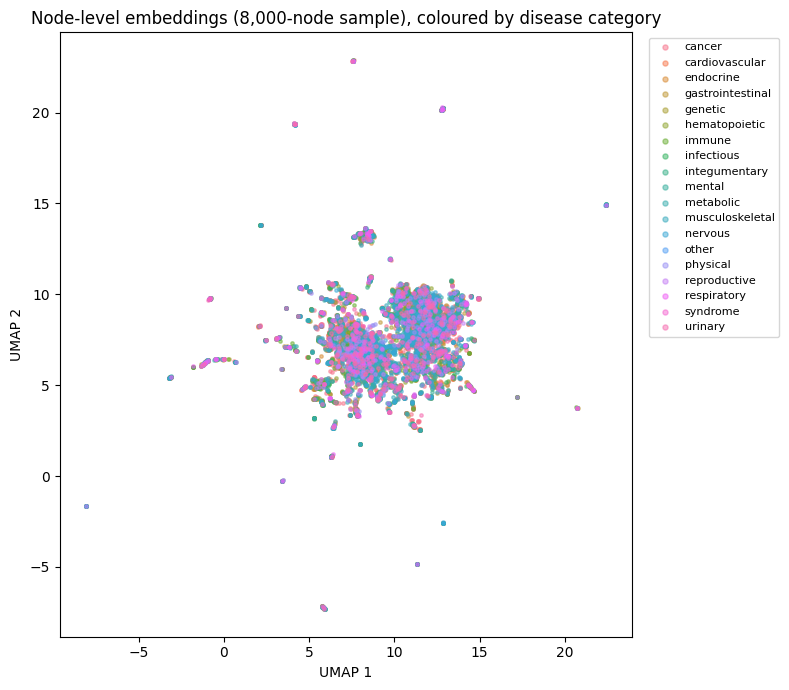

In [52]:
N_NODE_SAMPLE = 8000

rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(node_export["embeddings"]), size=N_NODE_SAMPLE, replace=False)
node_sample_emb = node_export["embeddings"][sample_idx]
node_sample_cat = node_export["category"][sample_idx]

node_umap = umap.UMAP(random_state=SEED).fit_transform(node_sample_emb)

fig, ax = plt.subplots(figsize=(8, 7))
for cat in cats:
    mask = node_sample_cat == cat
    ax.scatter(node_umap[mask, 0], node_umap[mask, 1], s=6, alpha=0.5, color=palette[cat], label=cat)
ax.set(xlabel="UMAP 1", ylabel="UMAP 2",
       title=f"Node-level embeddings ({N_NODE_SAMPLE:,}-node sample), coloured by disease category")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, markerscale=1.5)
plt.tight_layout(); plt.show()

#### Sanity check: is the embedding space actually being used?

A UMAP plot always finds *some* 2D layout, whether or not the underlying space has real structure — worth checking directly rather than trusting the picture. PCA on the graph- and node-level embeddings shows how much of the variance sits in just the first couple of components; if that number were close to 100%, the whole 128-dim space would have collapsed onto a line or a plane and the UMAP picture above would be showing noise, not structure.

In [53]:
from sklearn.decomposition import PCA

for name, emb in [("graph", graph_export["embeddings"]), ("node", node_sample_emb)]:
    pca = PCA(n_components=5).fit(emb)
    cum = np.cumsum(pca.explained_variance_ratio_)
    print(f"{name:>5}-level: PC1 alone {pca.explained_variance_ratio_[0]:.1%} | "
          f"first 5 PCs {cum[-1]:.1%} of variance")

graph-level: PC1 alone 24.4% | first 5 PCs 61.5% of variance
 node-level: PC1 alone 7.3% | first 5 PCs 20.9% of variance


#### Saving the three levels

Node, edge and graph embeddings, saved separately so they can be used to train the three GEA SAEs (node-, edge- and graph-level) afterwards. All three are 128-dimensional, which is the point of writing the edge level as a ratio rather than a concatenation. Entity ids follow `gea.gea`'s own naming convention (`ENTITY_SEP`, `GENE_PAIR_SEP`) so they read the same way as the LIONESS exports do. Edge-level is by far the largest (one row per interaction per disease), so it's stored as `float16`.

In [54]:
EMBEDDINGS_DIR = OUT_DIR / "embeddings"
EMBEDDINGS_DIR.mkdir(parents=True, exist_ok=True)

paths = {
    "graph": save_embeddings(EMBEDDINGS_DIR / "mask_gnn_graph.npz", graph_export),
    "node": save_embeddings(EMBEDDINGS_DIR / "mask_gnn_node.npz", node_export),
    "edge": save_embeddings(EMBEDDINGS_DIR / "mask_gnn_edge.npz", edge_export),
}
for level, path in paths.items():
    size_mb = Path(path).stat().st_size / 1e6
    print(f"{level:>5}: {path}  ({size_mb:.0f} MB)")

graph: data/mask-the-interactome/embeddings/mask_gnn_graph.npz  (0 MB)
 node: data/mask-the-interactome/embeddings/mask_gnn_node.npz  (252 MB)
 edge: data/mask-the-interactome/embeddings/mask_gnn_edge.npz  (1848 MB)


## Sparse Autoencoders

### Setup

Each SAE trains directly on the embeddings already saved to disk — this section doesn't depend on anything from the GNN training kernel state, only the three `.npz` files.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

import gea.gea as gea_module
from gea.gea import ShallowSAE, train_sae, set_seed

DATA_DIR = Path("data/diseases")
OUT_DIR = Path("data/mask-the-interactome")
EMBEDDINGS_DIR = OUT_DIR / "embeddings"
SEED = 42
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Same train/val disease split the GNN used, saved inside its own checkpoint — node- and edge-level
# training below restricts itself to train_doids so val_doids stays genuinely unseen by everything,
# including the concept-annotation test later in this notebook.
gnn_ckpt = torch.load(OUT_DIR / "mask_gnn.pt", map_location="cpu", weights_only=False)
train_doids, val_doids = gnn_ckpt["train_doids"], gnn_ckpt["val_doids"]

print(f"device: {device}")
print(f"{len(train_doids):,} GNN-train diseases | {len(val_doids):,} GNN-held-out diseases")

device: cuda
736 GNN-train diseases | 184 GNN-held-out diseases


### A minimal dataset for `train_sae`

`gea.gea.train_sae` only ever reads `batch['embedding']`, but `gea.dataloader.EmbeddingDataset` also requires `prediction`/`target` fields from the LIONESS/GNNModel pipeline that our unsupervised export never produced. A dataset that wraps just the embeddings is all that's actually needed here.

In [2]:
class EmbeddingOnlyDataset(Dataset):
    def __init__(self, embeddings):
        self.embeddings = torch.tensor(np.asarray(embeddings).astype(np.float32))

    def __len__(self):
        return len(self.embeddings)

    def __getitem__(self, idx):
        return {"embedding": self.embeddings[idx]}

### Training one SAE per level

`ShallowSAE` is a plain dictionary-learning autoencoder (linear encoder, ReLU, linear decoder, L1
sparsity penalty, decoder weights renormalised every step so features can't collapse to zero).
Graph-level trains on all 920 diseases — it's never used in the held-out concept-annotation test
below, so there is nothing to protect it from. Node- and edge-level train **only on `train_doids`**,
the same diseases the GNN itself trained on: that way `val_doids` stays genuinely unseen by the SAE
too, and the held-out test later in this notebook doesn't need a second, separately-trained SAE just
to get that guarantee — training the same dictionary twice would be pure waste. The progress bar is
muted (`train_sae`'s own `tqdm` swapped out during the call) so it doesn't flood the notebook with
thousands of progress lines.

In [3]:
class _NoOpProgressBar:
    """Drop-in tqdm replacement: same interface, does nothing — keeps train_sae's
    per-step progress bar out of the saved notebook (it would otherwise dump
    thousands of lines of text into the cell output)."""
    def __init__(self, iterable, **kwargs):
        self._iterable = iterable

    def __iter__(self):
        return iter(self._iterable)

    def set_postfix(self, **kwargs):
        pass

    def update(self, *args, **kwargs):
        pass

    def close(self):
        pass


def train_disease_sae(level, latent_dim, epochs, batch_size=256, val_frac=0.1, doid_subset=None):
    data = np.load(EMBEDDINGS_DIR / f"mask_gnn_{level}.npz", allow_pickle=True)
    embeddings = data["embeddings"]
    if doid_subset is not None:
        embeddings = embeddings[np.isin(data["doid"], doid_subset)]
    dataset = EmbeddingOnlyDataset(embeddings)

    n_val = max(1, int(val_frac * len(dataset)))
    train_ds, val_ds = random_split(
        dataset, [len(dataset) - n_val, n_val],
        generator=torch.Generator().manual_seed(SEED),
    )
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    sae = ShallowSAE(in_dim=dataset.embeddings.shape[1], latent_dim=latent_dim)
    model_path = EMBEDDINGS_DIR / f"sae_{level}.pt"
    loss_path = EMBEDDINGS_DIR / f"sae_{level}_loss.csv"

    scope = (f"{len(dataset):,} rows from {len(doid_subset):,} diseases" if doid_subset is not None
             else f"{len(dataset):,} rows")
    print(f"=== {level}-level SAE: {scope}, {dataset.embeddings.shape[1]} -> {latent_dim} dims ===")

    _tqdm, gea_module.tqdm = gea_module.tqdm, _NoOpProgressBar
    try:
        train_sae(sae, train_loader, val_loader, device, epochs=epochs,
                  model_path=str(model_path), loss_path=str(loss_path))
    finally:
        gea_module.tqdm = _tqdm

    sae.load_state_dict(torch.load(model_path))  # keep the best-val checkpoint, not the last epoch
    return sae

#### Graph-level SAE

In [58]:
graph_sae = train_disease_sae("graph", latent_dim=1024, epochs=200, batch_size=128)

=== graph-level SAE: 920 rows, 128 -> 1024 dims ===

Training losses saved to: data/mask-the-interactome/embeddings/sae_graph_loss.csv
Best validation loss: 0.0247 at epoch 132


#### Node-level SAE

Trained only on `train_doids` rows (see above).

In [59]:
node_sae = train_disease_sae("node", latent_dim=1024, epochs=30, batch_size=256, doid_subset=train_doids)

=== node-level SAE: 362,063 rows from 736 diseases, 128 -> 1024 dims ===

Training losses saved to: data/mask-the-interactome/embeddings/sae_node_loss.csv
Best validation loss: 0.0472 at epoch 29


#### Edge-level SAE

Trained only on `train_doids` rows (see above).

In [60]:
edge_sae = train_disease_sae("edge", latent_dim=1024, epochs=20, batch_size=1024, doid_subset=train_doids)

=== edge-level SAE: 4,584,044 rows from 736 diseases, 128 -> 1024 dims ===

Training losses saved to: data/mask-the-interactome/embeddings/sae_edge_loss.csv
Best validation loss: 0.0034 at epoch 19


#### Training curves, all three levels

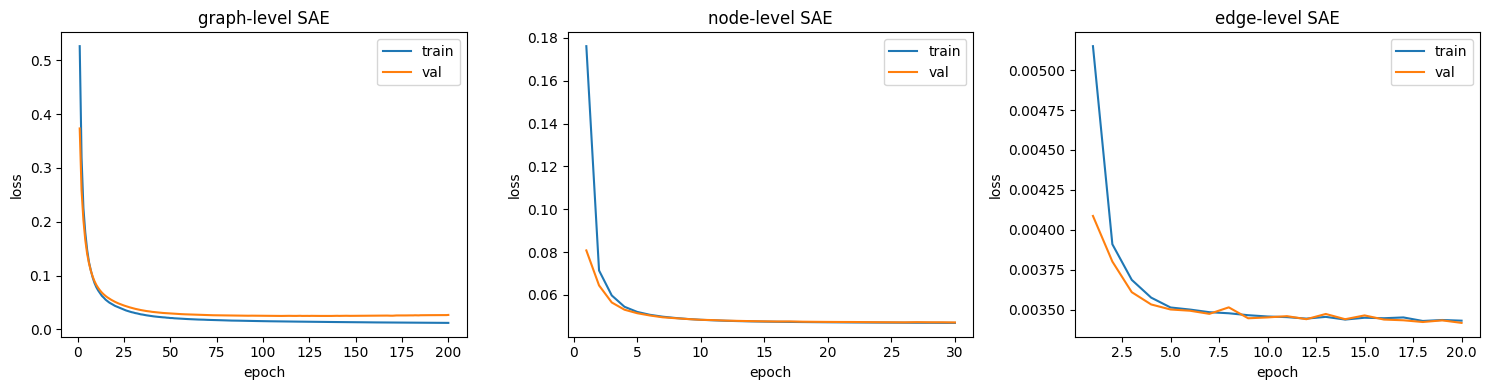

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, level in zip(axes, ["graph", "node", "edge"]):
    loss_df = pd.read_csv(EMBEDDINGS_DIR / f"sae_{level}_loss.csv")
    ax.plot(loss_df["epoch"], loss_df["train_loss"], label="train")
    ax.plot(loss_df["epoch"], loss_df["val_loss"], label="val")
    ax.set(xlabel="epoch", ylabel="loss", title=f"{level}-level SAE")
    ax.legend()
plt.tight_layout(); plt.show()

#### Saving the SAE weights

`train_sae` already checkpoints the best-validation state to disk during training (`sae_{level}.pt`, one per level) — this just confirms what's there.

In [62]:
sae_paths = {level: EMBEDDINGS_DIR / f"sae_{level}.pt" for level in ["graph", "node", "edge"]}
for level, path in sae_paths.items():
    size_kb = path.stat().st_size / 1e3
    print(f"{level:>5}: {path}  ({size_kb:.0f} KB)")

graph: data/mask-the-interactome/embeddings/sae_graph.pt  (1056 KB)
 node: data/mask-the-interactome/embeddings/sae_node.pt  (1056 KB)
 edge: data/mask-the-interactome/embeddings/sae_edge.pt  (1056 KB)


## Evaluation of SAEs

### Analysis strategy

The three SAE levels are analysed as **parallel atlases** of the same disease-conditioned interactome.

1. **Graph-level SAE:** discover recurring **disease/network programs** from the disease embeddings.
2. **Program localization:** for a graph SAE feature in a disease, propagate its activation back through the graph representation and GNN to identify candidate **nodes and interactions** expressing that program.
3. **Node-level SAE:** independently discover **contextual protein states** across diseases.
4. **Edge-level SAE:** independently discover **contextual interaction states/motifs** across diseases.

Ontology and disease-category information are used only as **post-hoc biological validation**. They do not define what an SAE feature is.

> **Evaluation note.** The existing `sae_graph.pt` was trained on all 920 disease embeddings in the preceding notebook section. The graph-program atlas below is therefore an exploratory/descriptive analysis over the full disease set; any held-out generalization claim for graph SAE concepts would require retraining the graph SAE on the GNN training diseases only.

In [2]:
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_add_pool
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.stats import hypergeom
from statsmodels.stats.multitest import multipletests

from gea.gea import ShallowSAE, set_seed

DATA_DIR = Path("data/diseases")
OUT_DIR = Path("data/mask-the-interactome")
EMBEDDINGS_DIR = OUT_DIR / "embeddings"
SEED = 42
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Saved outputs from the previous sections.
graph_export = np.load(EMBEDDINGS_DIR / "mask_gnn_graph.npz", allow_pickle=True)
node_export = np.load(EMBEDDINGS_DIR / "mask_gnn_node.npz", allow_pickle=True)
edge_export = np.load(EMBEDDINGS_DIR / "mask_gnn_edge.npz", allow_pickle=True)

disease_meta = pd.read_csv(DATA_DIR / "disease_categories.tsv", sep="\t")
disease_names = disease_meta.set_index("doid")["doid_name"].to_dict()
category_by_doid = disease_meta.set_index("doid")["category"].to_dict()

# The same SAE architecture/checkpoints trained above.
graph_sae = ShallowSAE(in_dim=graph_export["embeddings"].shape[1], latent_dim=1024)
graph_sae.load_state_dict(torch.load(EMBEDDINGS_DIR / "sae_graph.pt", map_location="cpu"))
graph_sae.to(device).eval()

node_sae = ShallowSAE(in_dim=node_export["embeddings"].shape[1], latent_dim=1024)
node_sae.load_state_dict(torch.load(EMBEDDINGS_DIR / "sae_node.pt", map_location="cpu"))
node_sae.to(device).eval()

edge_sae = ShallowSAE(in_dim=edge_export["embeddings"].shape[1], latent_dim=1024)
edge_sae.load_state_dict(torch.load(EMBEDDINGS_DIR / "sae_edge.pt", map_location="cpu"))
edge_sae.to(device).eval()

# The SAE training above used the same disease split as the GNN.
gnn_ckpt = torch.load(OUT_DIR / "mask_gnn.pt", map_location="cpu", weights_only=False)
train_doids, val_doids = gnn_ckpt["train_doids"], gnn_ckpt["val_doids"]

print(f"device: {device}")
print(f"graph: {graph_export['embeddings'].shape}")
print(f"node:  {node_export['embeddings'].shape}")
print(f"edge:  {edge_export['embeddings'].shape}")
print(f"disease split: {len(train_doids)} train / {len(val_doids)} held-out")

device: cuda
graph: (920, 128)
node:  (455120, 128)
edge:  (5796601, 128)
disease split: 736 train / 184 held-out


### 1. Graph SAE: build the disease-program atlas

For each disease, the Graph SAE produces a sparse activation vector

\[
 a_d \in \mathbb{R}^{1024}.
\]

A feature is therefore a latent **network program** when it recurs across disease contexts. The first question is not which ontology term it matches, but **where and how often it appears across the disease atlas**.

In [2]:
def sae_activations(sae, embeddings, batch_size=8192, selected=None):
    """Run an SAE in batches; optionally return only selected latent features."""
    embeddings = np.asarray(embeddings, dtype=np.float32)
    outputs = []
    with torch.no_grad():
        for start in range(0, len(embeddings), batch_size):
            xb = torch.from_numpy(embeddings[start:start+batch_size]).to(device)
            z, _ = sae(xb)
            z = z.cpu().numpy()
            if selected is not None:
                z = z[:, selected]
            outputs.append(z)
    return np.concatenate(outputs, axis=0)


graph_acts = sae_activations(graph_sae, graph_export["embeddings"], batch_size=4096)
graph_feature_names = np.array([f"feature_{i}" for i in range(graph_acts.shape[1])])
graph_firing = graph_acts > 0

graph_table = pd.DataFrame({
    "doid": graph_export["doid"],
    "doid_name": [disease_names.get(x, str(x)) for x in graph_export["doid"]],
    "category": [category_by_doid.get(x, "other") for x in graph_export["doid"]],
})

print(f"{len(graph_table):,} diseases x {graph_acts.shape[1]:,} graph SAE features")
print(f"median active features / disease: {np.median(graph_firing.sum(1)):.0f}")

920 diseases x 1,024 graph SAE features
median active features / disease: 43


In [3]:
# Descriptive feature statistics.
categories = sorted(graph_table["category"].unique())
category_labels = graph_table["category"].to_numpy()

rows = []
for k in range(graph_acts.shape[1]):
    active = graph_firing[:, k]
    rates = {c: active[category_labels == c].mean() for c in categories}
    best_cat = max(rates, key=rates.get)
    rows.append({
        "feature": k,
        "active_diseases": int(active.sum()),
        "global_rate": float(active.mean()),
        "mean_active": float(graph_acts[active, k].mean()) if active.any() else 0.0,
        "best_category": best_cat,
        "best_category_rate": float(rates[best_cat]),
        "category_selectivity": float(rates[best_cat] / max(active.mean(), 1e-9)),
    })

graph_feature_stats = pd.DataFrame(rows)

alive = graph_feature_stats.query("active_diseases >= 5 and global_rate >= 0.01").copy()
print(f"{len(alive)}/1024 features are recurrent enough for atlas-level analysis")
print("\nMost selective recurrent features:")
print(
    alive.sort_values(["category_selectivity", "active_diseases"], ascending=[False, False])
         .head(15)
         .to_string(index=False, float_format=lambda x: f"{x:.3f}")
)

516/1024 features are recurrent enough for atlas-level analysis

Most selective recurrent features:
 feature  active_diseases  global_rate  mean_active best_category  best_category_rate  category_selectivity
     613               10        0.011        0.062         other               0.500                46.000
     183               13        0.014        0.081         other               0.500                35.385
     391               13        0.014        0.092         other               0.500                35.385
     164               15        0.016        0.053         other               0.500                30.667
     859               16        0.017        0.151         other               0.500                28.750
     965               16        0.017        0.088         other               0.500                28.750
      34               18        0.020        0.064         other               0.500                25.556
     371               18        0.0

#### What does a graph feature do across diseases?

For each feature we can inspect its strongest disease contexts. This is the primary biological object produced by the Graph SAE: a **latent network program together with the disease contexts in which it is expressed**.

In [4]:
def top_diseases_for_graph_feature(feature_id, top_n=15, min_activation=0.0):
    idx = np.flatnonzero(graph_acts[:, feature_id] > min_activation)
    order = idx[np.argsort(graph_acts[idx, feature_id])[::-1]]
    out = graph_table.iloc[order[:top_n]].copy()
    out["activation"] = graph_acts[order[:top_n], feature_id]
    return out

# Pick one recurrent, reasonably selective feature as an automatically generated example.
case_feature = int(
    alive.sort_values(["category_selectivity", "active_diseases"], ascending=[False, False])
         .iloc[0]["feature"]
)

print(f"Example graph program: feature_{case_feature}")
print(top_diseases_for_graph_feature(case_feature).to_string(index=False))

Example graph program: feature_613
        doid                       doid_name        category  activation
    DOID:890 Mitochondrial encephalomyopathy musculoskeletal    0.256070
  DOID:10892                     Hypospadias        physical    0.154512
  DOID:13938                      Amenorrhea    reproductive    0.084443
   DOID:3650                 Lactic acidosis       metabolic    0.047481
   DOID:4501        Orofaciodigital syndrome        syndrome    0.021752
DOID:0080832       Mild cognitive impairment          mental    0.017457
   DOID:5723                   Optic atrophy         nervous    0.012403
  DOID:11613                Hyperandrogenism       endocrine    0.009568
   DOID:8725               Vascular dementia          mental    0.007049
DOID:0080546       non-alcoholic fatty liver           other    0.005567


### 2. Disease-to-disease structure from the Graph SAE

Each disease now has a sparse **network-program fingerprint**. Similarity between diseases can therefore be computed in the latent program space, rather than directly from the original gene lists.

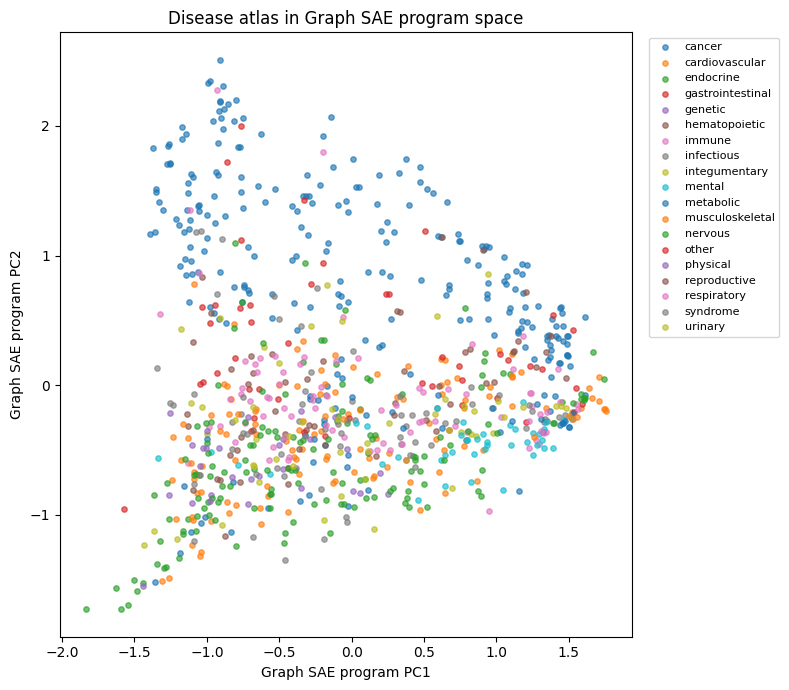

PC1 variance: 16.8%
PC2 variance: 13.4%


In [5]:
# PCA is used only for a compact visualization; all similarity calculations stay in the SAE space.
pca = PCA(n_components=2, random_state=SEED)
graph_xy = pca.fit_transform(graph_acts)

fig, ax = plt.subplots(figsize=(8, 7))
for category in sorted(graph_table["category"].unique()):
    m = graph_table["category"].to_numpy() == category
    ax.scatter(graph_xy[m, 0], graph_xy[m, 1], s=15, alpha=0.65, label=category)
ax.set(xlabel="Graph SAE program PC1", ylabel="Graph SAE program PC2",
       title="Disease atlas in Graph SAE program space")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

print(f"PC1 variance: {pca.explained_variance_ratio_[0]:.1%}")
print(f"PC2 variance: {pca.explained_variance_ratio_[1]:.1%}")

In [6]:
# Feature co-activation: which latent programs repeatedly occur together?
active_features = np.flatnonzero(graph_firing.sum(axis=0) >= 5)
binary = graph_firing[:, active_features].astype(np.float32)

coactivation = (binary.T @ binary) / max(binary.shape[0], 1)
np.fill_diagonal(coactivation, 0.0)

pairs = []
for i in range(len(active_features)):
    for j in range(i + 1, len(active_features)):
        if coactivation[i, j] > 0:
            pairs.append((active_features[i], active_features[j], coactivation[i, j]))
coactivation_pairs = pd.DataFrame(pairs, columns=["feature_a", "feature_b", "coactivation_rate"])

print("Top recurrent feature co-activations:")
print(coactivation_pairs.sort_values("coactivation_rate", ascending=False).head(20).to_string(index=False))

Top recurrent feature co-activations:
 feature_a  feature_b  coactivation_rate
       302        520           0.570652
       520        659           0.534783
       411        520           0.529348
       157        520           0.513043
       443        520           0.510870
       453        520           0.502174
       302        659           0.484783
       428        520           0.482609
       157        302           0.482609
       520        791           0.469565
       302        411           0.468478
       443        659           0.467391
       157        659           0.456522
       157        411           0.445652
       411        428           0.441304
       453        659           0.440217
       443        453           0.438043
       302        443           0.433696
       428        443           0.433696
       302        453           0.425000


### 3. Post-hoc validation of graph programs

Disease categories are **external validation**, not training targets. A useful graph SAE feature can be shared by several categories, restricted to a subset of one category, or associated with a finer disease concept. Therefore we report category enrichment as characterization rather than as the definition of the feature.

In [7]:
# One-vs-rest category association using the same relative activation idea as the old notebook,
# but retained only as a validation table.
category_validation = []
for k in range(graph_acts.shape[1]):
    col = graph_acts[:, k]
    if not np.any(col > 0):
        continue
    threshold = 0.30 * col.max()
    pred = col >= threshold
    for category in categories:
        truth = category_labels == category
        tp = np.sum(pred & truth)
        precision = tp / max(pred.sum(), 1)
        recall = tp / max(truth.sum(), 1)
        f1 = 2 * precision * recall / max(precision + recall, 1e-12)
        category_validation.append((k, category, f1, int(pred.sum()), int(truth.sum())))

category_validation = pd.DataFrame(
    category_validation,
    columns=["feature", "category", "f1", "n_pred", "n_category"]
)

best_validation = (
    category_validation.sort_values(["feature", "f1"], ascending=[True, False])
                       .groupby("feature", as_index=False).head(1)
                       .sort_values("f1", ascending=False)
)

print("Top graph-feature/category associations (validation only):")
print(best_validation.head(20).to_string(index=False, float_format=lambda x: f"{x:.3f}"))

Top graph-feature/category associations (validation only):
 feature        category    f1  n_pred  n_category
     443          cancer 0.754     212         210
      67          cancer 0.707     169         210
     659          cancer 0.603     168         210
     495           other 0.500       2           2
     332           other 0.500       2           2
     396           other 0.500       2           2
     327      infectious 0.470      93          39
     955          mental 0.447     109          43
     453          cancer 0.412     159         210
     562           other 0.400       3           2
     446           other 0.400       3           2
     816           other 0.400       3           2
     507        syndrome 0.400      12          33
     136 musculoskeletal 0.388      96          64
     716          cancer 0.387     126         210
     100          cancer 0.378     192         210
     411         nervous 0.377     120         124
    1019   integumentar

### 4. Localizing a graph program back onto its disease network

The Graph SAE tells us **what network program** is active. The next step asks **where that program is expressed**.

For a selected disease and Graph SAE feature, we backpropagate the feature activation through

$[ \text{Graph SAE} \rightarrow g_d \rightarrow h_i^{(d)} ]$

and through the GNN message passing to obtain node and interaction saliency.

These are **candidate localization scores**, not causal effects.

In [9]:
# Rebuild the contextual PyG graphs and the trained GNN so localization can be run directly from this section.
import pickle
import torch.nn as nn
from torch_geometric.data import Data
from gea.utils import compress_embeddings_pca

esm_reduced_dim = 512

h_dim = esm_reduced_dim  # hidden dim for GCN layers
z_dim = 128
proj_dim = 64            # context head

class FiLM(nn.Module):
    """Per-node feature-wise modulation conditioned on the disease state (m, c)."""

    def __init__(self, hidden_dim, cond_dim=2, film_hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cond_dim, film_hidden),
            nn.ReLU(),
            nn.Linear(film_hidden, 2 * hidden_dim),
        )
        nn.init.zeros_(self.net[-1].weight)  # start at gamma = 1, beta = 0 (plain residual GCN)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, h, cond):
        gamma, beta = self.net(cond).chunk(2, dim=-1)
        return (1.0 + gamma) * h + beta

class MaskedInteractomeGNN(nn.Module):
    def __init__(self, esm_dim, hidden_dim=h_dim, out_dim=z_dim, n_layers=3, dropout=0.2):
        super().__init__()
        self.proj = nn.Linear(esm_dim + 2, hidden_dim)
        self.convs = nn.ModuleList([GCNConv(hidden_dim, hidden_dim) for _ in range(n_layers)])
        self.films = nn.ModuleList([FiLM(hidden_dim) for _ in range(n_layers)])
        self.out_proj = nn.Linear(hidden_dim, out_dim)
        self.dropout = dropout

        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * out_dim, out_dim), nn.ReLU(), nn.Linear(out_dim, 1)
        )
        self.context_head = nn.Linear(out_dim, proj_dim)

    def encode(self, x, edge_index, edge_weight, hide=None):
        """`hide` zeroes (m, c) for the given nodes, everywhere they would otherwise be read."""
        cond = x[:, :2]
        if hide is not None:
            cond = cond.masked_fill(hide.unsqueeze(-1), 0.0)

        h = self.proj(torch.cat([cond, x[:, 2:]], dim=1))
        for conv, film in zip(self.convs, self.films):
            h = h + F.relu(conv(h, edge_index, edge_weight))
            h = film(h, cond)
            h = F.dropout(h, p=self.dropout, training=self.training)
        return self.out_proj(h)

    def decode_edges(self, h, edge_label_index):
        src, dst = edge_label_index
        pair = torch.cat([h[src] * h[dst], (h[src] - h[dst]).abs()], dim=-1)
        return self.edge_mlp(pair).squeeze(-1)

    def context_scores(self, h, mask, hide, batch, num_graphs):
        """Cosine similarity of every node to its own graph's visible-disease-gene prototype."""
        z = F.normalize(self.context_head(h), dim=-1)
        visible = ((mask > 0.5) & ~hide).float().unsqueeze(-1)
        total = global_add_pool(z * visible, batch, size=num_graphs)
        count = global_add_pool(visible, batch, size=num_graphs).clamp(min=1.0)
        prototype = F.normalize(total / count, dim=-1)
        return (z * prototype[batch]).sum(dim=-1)

with open(OUT_DIR / "context_graphs.pkl", "rb") as f:
    context_graphs = pickle.load(f)

# Reproduce the same whitened ESM representation used during GNN training.
protein_to_esm_raw = {}
for G in context_graphs.values():
    for p in G.nodes:
        if p not in protein_to_esm_raw:
            protein_to_esm_raw[p] = G.nodes[p]["x"][2:]

proteins_ordered = list(protein_to_esm_raw)
esm_raw = torch.stack([protein_to_esm_raw[p] for p in proteins_ordered]).float()
esm_white = compress_embeddings_pca(esm_raw, n_components=512, whiten=True)
protein_to_esm_white = dict(zip(proteins_ordered, esm_white))


def to_pyg_from_context(doid, G):
    nodes = sorted(G.nodes())
    idx = {n: i for i, n in enumerate(nodes)}
    cond = torch.stack([G.nodes[n]["x"][:2] for n in nodes]).float()
    esm = torch.stack([protein_to_esm_white[n] for n in nodes]).float()
    x = torch.cat([cond, esm], dim=1)

    edges = list(G.edges(data="combined_score"))
    src = [idx[u] for u, v, _ in edges] + [idx[v] for u, v, _ in edges]
    dst = [idx[v] for u, v, _ in edges] + [idx[u] for u, v, _ in edges]
    weight = [s / 1000.0 for _, _, s in edges] * 2
    return Data(
        x=x,
        edge_index=torch.tensor([src, dst], dtype=torch.long),
        edge_attr=torch.tensor(weight, dtype=torch.float32).view(-1, 1),
        doid=doid,
    )

pyg_graphs_analysis = {
    doid: to_pyg_from_context(doid, G) for doid, G in context_graphs.items()
}

# MaskedInteractomeGNN was defined earlier in the notebook. Load exactly the trained parameters.
gnn_model = MaskedInteractomeGNN(esm_dim=512).to(device)
gnn_model.load_state_dict(gnn_ckpt["model_state_dict"])
gnn_model.eval()

print(f"reconstructed {len(pyg_graphs_analysis):,} contextual graphs for localization")

PCA: 1280→512 dims, 95.7% variance retained.
reconstructed 920 contextual graphs for localization


In [10]:
def graph_program_localization(doid, feature_id, top_n_nodes=20, top_n_edges=30):
    """Gradient x input localization of one Graph SAE feature in one disease graph.

    Node score: |h * d(feature)/dh| summed over embedding dimensions.
    Edge score: |w * d(feature)/dw|, aggregated over the two directed copies of each PPI.
    """
    data = pyg_graphs_analysis[doid]
    nodes = sorted(context_graphs[doid].nodes())

    x = data.x.to(device)
    edge_index = data.edge_index.to(device)
    edge_weight = data.edge_attr.squeeze(-1).to(device).detach().clone().requires_grad_(True)

    gnn_model.zero_grad(set_to_none=True)
    graph_sae.zero_grad(set_to_none=True)

    h = gnn_model.encode(x, edge_index, edge_weight)
    h.retain_grad()

    m = x[:, 0]
    c = x[:, 1]
    w_pos = (m * c).unsqueeze(-1)
    w_neg = (1.0 - m).unsqueeze(-1)
    g_pos = (w_pos * h).sum(0) / w_pos.sum().clamp(min=1e-8)
    g_neg = (w_neg * h).sum(0) / w_neg.sum().clamp(min=1e-8)
    g = g_pos - g_neg

    sae_activation, _ = graph_sae(g.unsqueeze(0))
    score = sae_activation[0, feature_id]
    score.backward()

    node_attr = (h.detach() * h.grad.detach()).abs().sum(dim=1).cpu().numpy()
    edge_attr = (edge_weight.detach() * edge_weight.grad.detach()).abs().cpu().numpy()

    # Aggregate the bidirectional GCN edges back into one undirected PPI.
    src = edge_index[0].detach().cpu().numpy()
    dst = edge_index[1].detach().cpu().numpy()
    pair_map = defaultdict(float)
    weight_map = defaultdict(float)
    for s, t, a, w in zip(src, dst, edge_attr, edge_weight.detach().cpu().numpy()):
        pair = tuple(sorted((nodes[s], nodes[t])))
        pair_map[pair] += float(a)
        weight_map[pair] = float(w)

    node_df = pd.DataFrame({
        "protein": nodes,
        "mask": x[:, 0].detach().cpu().numpy().astype(int),
        "confidence": x[:, 1].detach().cpu().numpy(),
        "attribution": node_attr,
    }).sort_values("attribution", ascending=False).reset_index(drop=True)

    edge_df = pd.DataFrame(
        [(a, b, score, weight_map[(a, b)]) for (a, b), score in pair_map.items()],
        columns=["protein_a", "protein_b", "attribution", "string_weight"],
    ).sort_values("attribution", ascending=False).reset_index(drop=True)

    return float(score.detach().cpu()), node_df.head(top_n_nodes), edge_df.head(top_n_edges)

# Automatically choose a disease-feature pair where the graph program is strongly active.
feature_order = graph_feature_stats.query("active_diseases >= 5").sort_values(
    ["category_selectivity", "active_diseases"], ascending=[False, False]
)
LOCALIZE_FEATURE = int(feature_order.iloc[0]["feature"])
localize_disease = top_diseases_for_graph_feature(LOCALIZE_FEATURE, top_n=1).iloc[0]["doid"]

feature_score, localized_nodes, localized_edges = graph_program_localization(
    localize_disease, LOCALIZE_FEATURE
)

print(f"localized feature_{LOCALIZE_FEATURE} in {disease_names.get(localize_disease, localize_disease)}")
print(f"Graph SAE activation: {feature_score:.4f}")
print("\nTop candidate node contributors:")
print(localized_nodes.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\nTop candidate interaction contributors:")
print(localized_edges.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

localized feature_396 in non-alcoholic fatty liver
Graph SAE activation: 0.0825

Top candidate node contributors:
        protein  mask  confidence  attribution
ENSP00000378408     1      0.6052       0.1809
ENSP00000373489     1      0.5012       0.1758
ENSP00000380432     1      0.5664       0.1712
ENSP00000385523     1      0.5514       0.1646
ENSP00000287820     1      0.5116       0.1506
ENSP00000216180     1      0.5916       0.1444
ENSP00000348069     1      0.5706       0.1440
ENSP00000389814     1      0.5232       0.1438
ENSP00000374014     1      0.5466       0.1381
ENSP00000447149     1      0.5268       0.1306
ENSP00000345282     1      0.4524       0.1200
ENSP00000333300     1      0.4720       0.1179
ENSP00000265641     1      0.4544       0.1173
ENSP00000304592     1      0.4674       0.1144
ENSP00000312652     1      0.5024       0.1134
ENSP00000221930     1      0.4378       0.1093
ENSP00000261693     1      0.4556       0.1084
ENSP00000415743     1      0.4634       

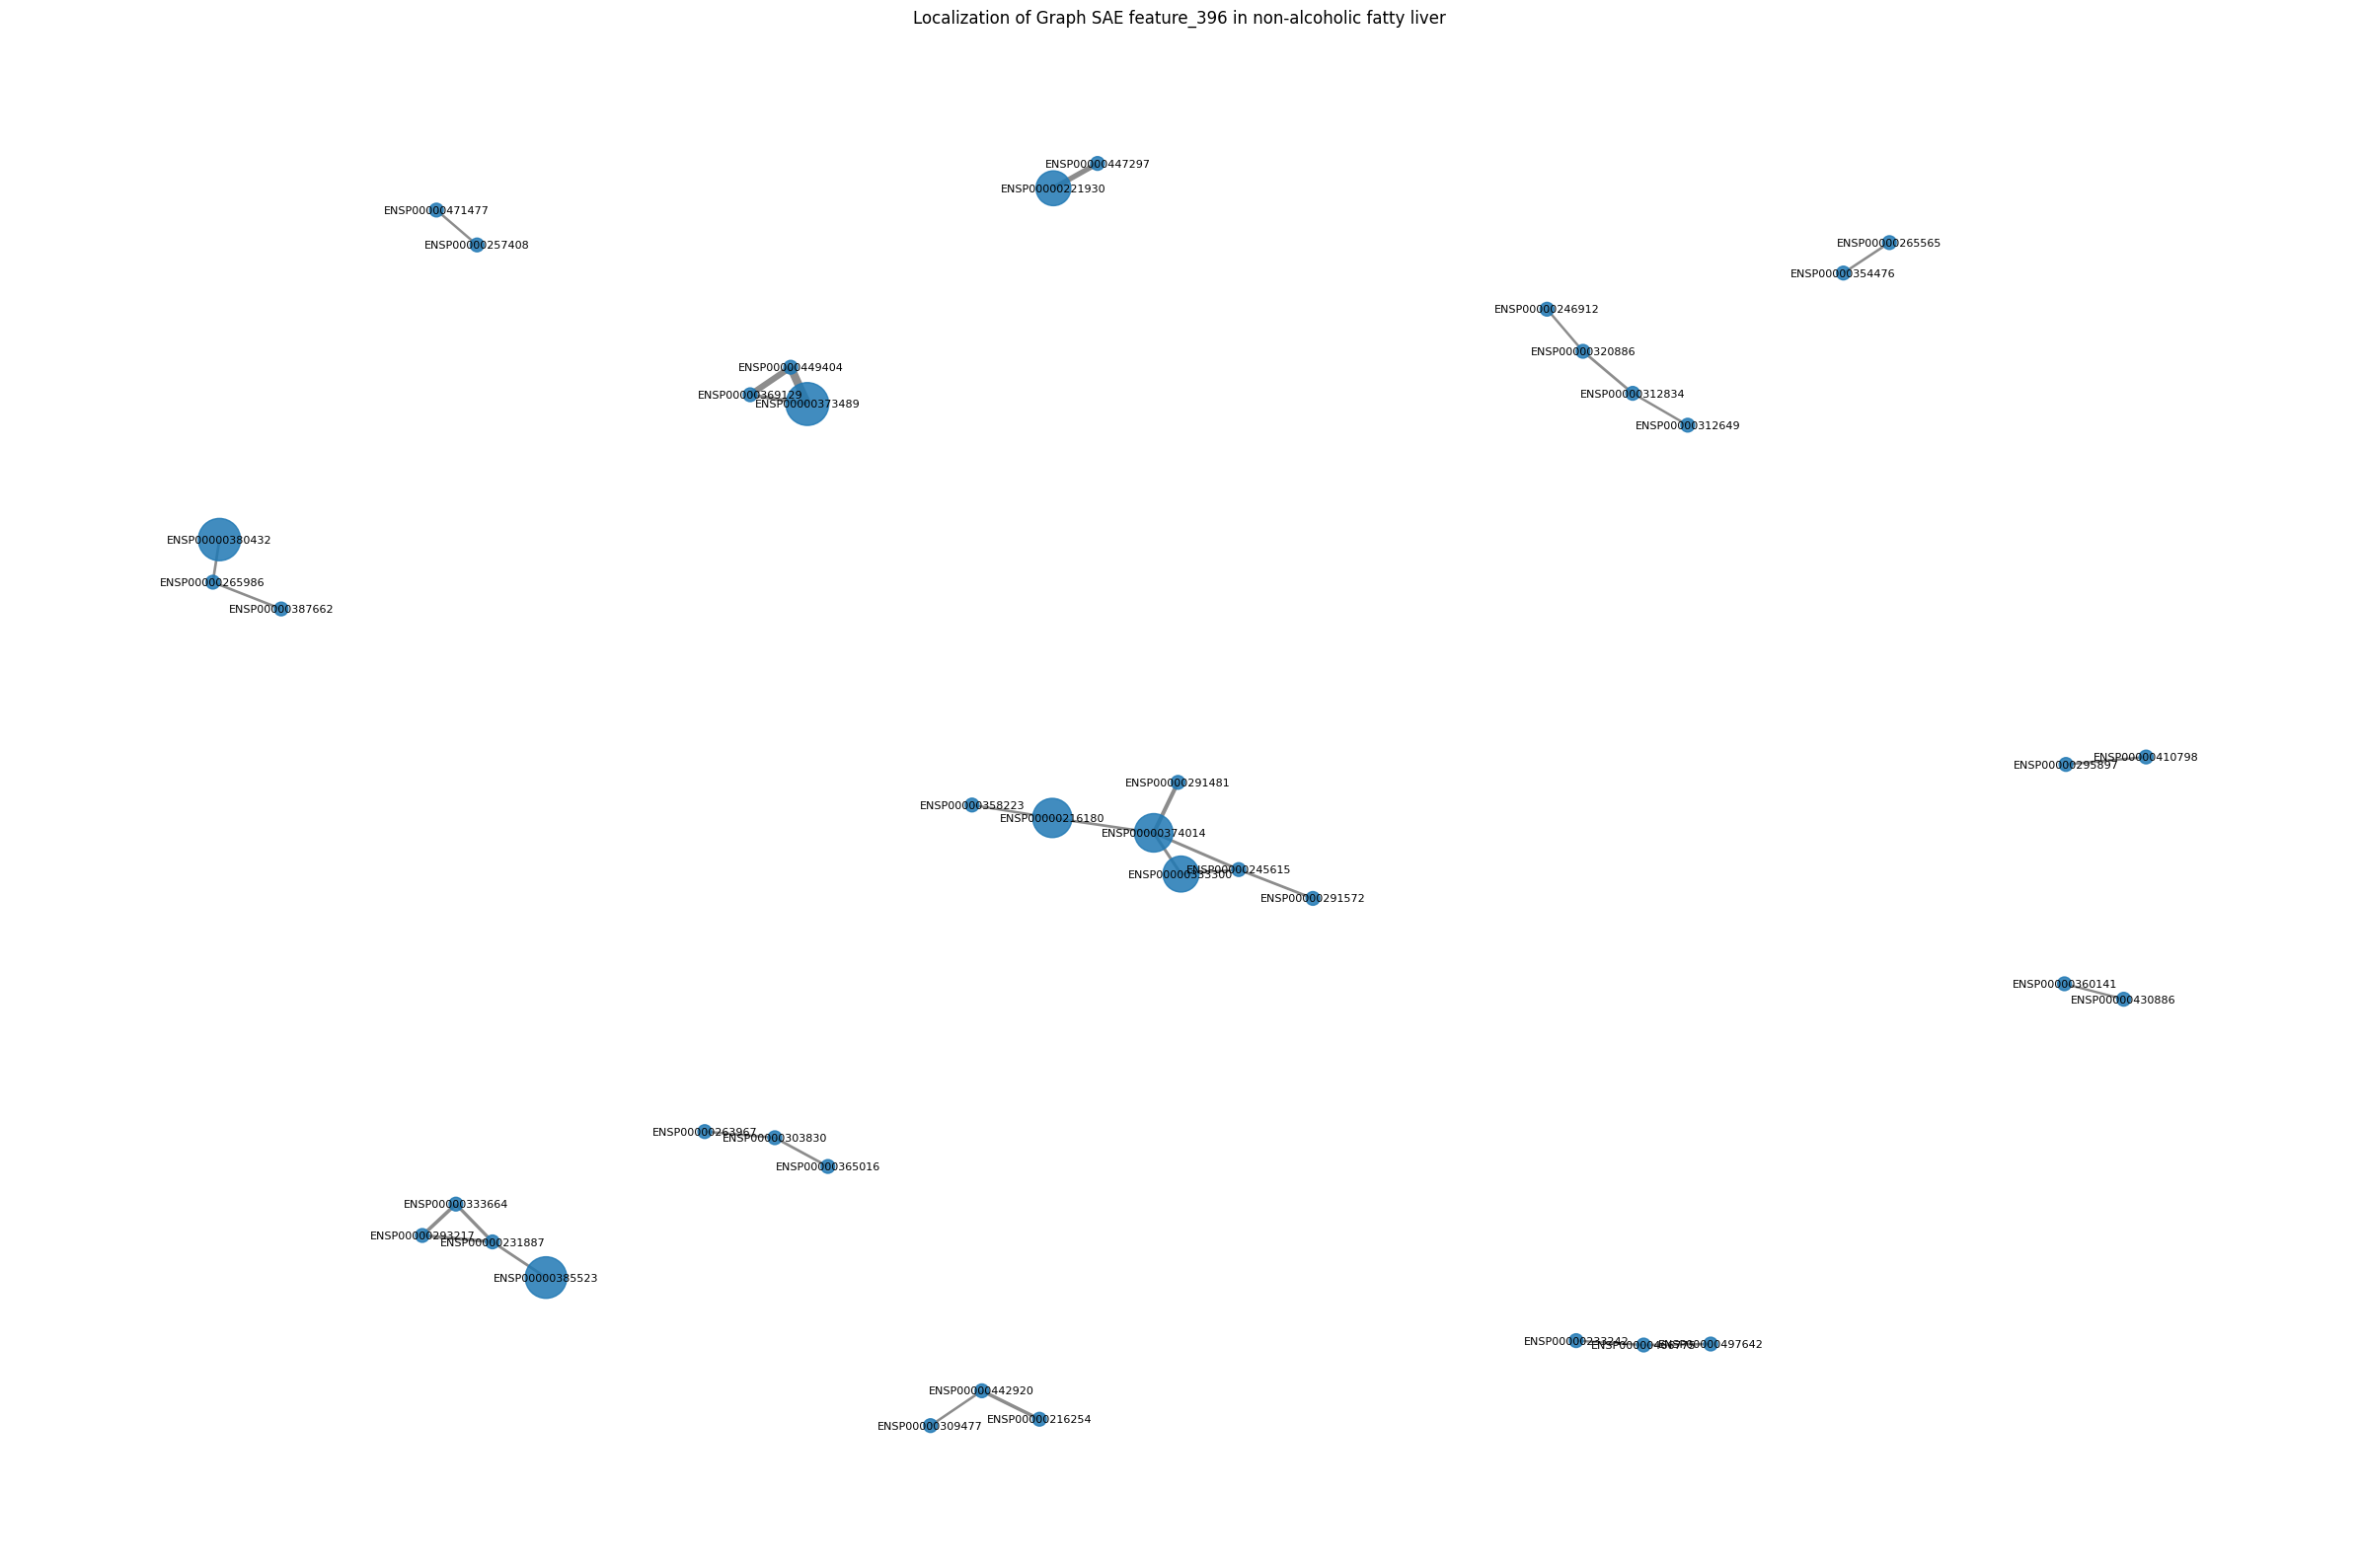

In [13]:
# Visualize the localized interaction subgraph for the selected graph program.
G_loc = nx.Graph()
for row in localized_edges.itertuples(index=False):
    G_loc.add_edge(row.protein_a, row.protein_b, attribution=row.attribution)

if len(G_loc):
    top_nodes = localized_nodes.set_index("protein")["attribution"].to_dict()
    edge_widths = [1 + 5 * G_loc[u][v]["attribution"] / max(localized_edges["attribution"].max(), 1e-9)
                   for u, v in G_loc.edges()]
    node_sizes = [100 + 900 * top_nodes.get(n, 0) / max(localized_nodes["attribution"].max(), 1e-9)
                  for n in G_loc.nodes()]

    pos = nx.spring_layout(G_loc, seed=SEED)
    fig, ax = plt.subplots(figsize=(24, 16))
    nx.draw_networkx_edges(G_loc, pos, width=edge_widths, alpha=0.45, ax=ax)
    nx.draw_networkx_nodes(G_loc, pos, node_size=node_sizes, alpha=0.85, ax=ax)
    nx.draw_networkx_labels(G_loc, pos, font_size=8, ax=ax)
    ax.set_title(f"Localization of Graph SAE feature_{LOCALIZE_FEATURE} in {disease_names.get(localize_disease, localize_disease)}")
    ax.axis("off")
    plt.tight_layout(); plt.show()
else:
    print("No localized edges available for this example.")

#### Is the localization recurrent across the diseases activating the same program?

A single disease example is illustrative but not enough to call a network mechanism recurrent. We therefore repeat the localization for the strongest disease contexts of one Graph SAE feature and aggregate the node/edge scores.

In [14]:
program_disease_table = top_diseases_for_graph_feature(LOCALIZE_FEATURE, top_n=5)

node_localization_records = []
edge_localization_records = []
for row in program_disease_table.itertuples(index=False):
    score, nodes_df, edges_df = graph_program_localization(row.doid, LOCALIZE_FEATURE, top_n_nodes=50, top_n_edges=100)
    nodes_df = nodes_df.copy()
    nodes_df["doid"] = row.doid
    nodes_df["graph_feature_activation"] = score
    edges_df = edges_df.copy()
    edges_df["doid"] = row.doid
    edges_df["graph_feature_activation"] = score
    node_localization_records.append(nodes_df)
    edge_localization_records.append(edges_df)

node_localization = pd.concat(node_localization_records, ignore_index=True)
edge_localization = pd.concat(edge_localization_records, ignore_index=True)

# Normalize within each disease so large graphs do not dominate the recurrence summary.
node_localization["relative_attribution"] = node_localization.groupby("doid")["attribution"].transform(
    lambda x: x / max(x.max(), 1e-12)
)
edge_localization["relative_attribution"] = edge_localization.groupby("doid")["attribution"].transform(
    lambda x: x / max(x.max(), 1e-12)
)

node_recurrence = (
    node_localization.groupby("protein")
    .agg(
        n_diseases=("doid", "nunique"),
        mean_relative_attribution=("relative_attribution", "mean"),
        max_relative_attribution=("relative_attribution", "max"),
    )
    .sort_values(["n_diseases", "mean_relative_attribution"], ascending=False)
)

edge_recurrence = (
    edge_localization.assign(pair=lambda x: x["protein_a"] + " -- " + x["protein_b"])
    .groupby("pair")
    .agg(
        n_diseases=("doid", "nunique"),
        mean_relative_attribution=("relative_attribution", "mean"),
        max_relative_attribution=("relative_attribution", "max"),
    )
    .sort_values(["n_diseases", "mean_relative_attribution"], ascending=False)
)

print("Top recurrent node localizations:")
print(node_recurrence.head(20).to_string(float_format=lambda x: f"{x:.3f}"))
print("\nTop recurrent interaction localizations:")
print(edge_recurrence.head(20).to_string(float_format=lambda x: f"{x:.3f}"))

Top recurrent node localizations:
                 n_diseases  mean_relative_attribution  max_relative_attribution
protein                                                                         
ENSP00000385675           5                      0.729                     0.991
ENSP00000398698           5                      0.623                     0.715
ENSP00000263341           5                      0.614                     0.736
ENSP00000295897           4                      0.572                     0.733
ENSP00000011653           4                      0.563                     0.705
ENSP00000378408           3                      0.834                     1.000
ENSP00000221930           3                      0.615                     0.631
ENSP00000229135           3                      0.600                     0.714
ENSP00000363089           3                      0.589                     0.598
ENSP00000412237           3                      0.555                     

### 4b. Biological characterization of a localized program

Once a graph program has been localized, pathway/GO/Reactome enrichment becomes a **validation layer**. The enrichment is applied to the localized proteins, not to the disease labels used to define the Graph SAE feature.

In [15]:
# Build the same concept dictionary used earlier in the notebook, now used only for post-hoc validation.
from gea_gene_nets.annotation_funcs import fetch_gene_sets, geneSetAnnotation, gene_set_matrix
import urllib.request

STRING_DIR = DATA_DIR / "string"
GENE_SET_LIBRARIES = ["KEGG_2021_Human", "Reactome_2022", "GO_Biological_Process_2023"]
TERM_MIN_GENES, TERM_MAX_GENES = 8, 300
ALIAS_URL = "https://stringdb-downloads.org/download/protein.aliases.v12.0/9606.protein.aliases.v12.0.txt.gz"
alias_file = STRING_DIR / "9606.protein.aliases.v12.0.txt.gz"
if not alias_file.exists():
    urllib.request.urlretrieve(ALIAS_URL, alias_file)

aliases = pd.read_csv(
    alias_file, sep="\t", compression="gzip", header=0,
    names=["protein", "alias", "source"],
)
symbols = aliases[aliases["source"] == "Ensembl_HGNC_symbol"].copy()
symbols["protein"] = symbols["protein"].str.removeprefix("9606.")
protein_to_symbol = symbols.drop_duplicates("protein").set_index("protein")["alias"].to_dict()

gene_universe = sorted(set(node_export["protein"]))
gene_sets = fetch_gene_sets(libraries=GENE_SET_LIBRARIES, organism="Human")
term_masks = geneSetAnnotation(
    gene_universe, gene_sets,
    ensembl_to_symbol=protein_to_symbol,
    min_genes=TERM_MIN_GENES,
    max_genes=TERM_MAX_GENES,
)
term_table = gene_set_matrix(term_masks, gene_universe)


def ora_on_proteins(proteins, min_hits=2, top_n=20):
    selected = set(p for p in proteins if p in set(term_table.index))
    if not selected:
        return pd.DataFrame(columns=["term", "hits", "term_size", "p", "fdr"])

    selected_idx = [term_table.index.get_loc(p) for p in selected]
    selected_mask = np.zeros(len(term_table), dtype=bool)
    selected_mask[selected_idx] = True
    M = len(term_table)
    n = int(selected_mask.sum())
    rows = []
    for term in term_table.columns:
        members = term_table[term].to_numpy(dtype=bool)
        K = int(members.sum())
        hits = int((selected_mask & members).sum())
        if hits < min_hits or K == 0:
            continue
        p = hypergeom.sf(hits - 1, M, K, n)
        rows.append((term, hits, K, p))

    if not rows:
        return pd.DataFrame(columns=["term", "hits", "term_size", "p", "fdr"])
    out = pd.DataFrame(rows, columns=["term", "hits", "term_size", "p"])
    out["fdr"] = multipletests(out["p"], method="fdr_bh")[1]
    return out.sort_values(["fdr", "p", "hits"]).head(top_n)

localized_proteins = node_recurrence.head(30).index.tolist()
enrichment = ora_on_proteins(localized_proteins)
print(f"Pathway validation on {len(localized_proteins)} recurrently localized proteins:")
print(enrichment.to_string(index=False, float_format=lambda x: f"{x:.3g}"))

KEGG_2021_Human: 320 terms
Reactome_2022: 1816 terms
GO_Biological_Process_2023: 5406 terms
Total: 7542 terms
5457/7542 terms with 8–300 of the 10488 genes (median 21 genes/term)
Pathway validation on 30 recurrently localized proteins:
                                                                                     term  hits  term_size        p      fdr
     GO_Biological_Process_2023 | Positive Regulation Of Cytokine Production (GO:0001819)    16        276 3.59e-18 1.83e-15
                                             KEGG_2021_Human | Inflammatory bowel disease    11         62 6.06e-18 1.83e-15
                                      KEGG_2021_Human | Non-alcoholic fatty liver disease    12        133 7.44e-16  1.5e-13
                                                                KEGG_2021_Human | Malaria     9         46  3.5e-15 5.28e-13
                                 KEGG_2021_Human | Cytokine-cytokine receptor interaction    14        281 7.05e-15 7.65e-13
              

### 5. Node SAE: a contextual protein-state atlas

The Node SAE is **not** used merely to give names to graph-program nodes. It is a second, independent decomposition of the contextual protein embeddings.

For protein \(i\), the relevant object is

\[
\{a_{i,d}: d \in D_i\},
\]

which asks:

> **What latent states can the same protein occupy under different disease contexts?**

The analysis below therefore focuses on context frequency, state diversity, and repeated protein-specific state patterns. Ontology is only a downstream validation layer.

In [17]:
def sae_feature_stats_streaming(sae, embeddings, batch_size=8192, n_features=1024):
    """Streaming prevalence/max/sum statistics; avoids materializing millions x 1024 activations."""
    embeddings = np.asarray(embeddings, dtype=np.float32)
    # n_features = sae.encoder.out_features
    max_val = np.zeros(n_features, dtype=np.float32)
    positive_count = np.zeros(n_features, dtype=np.int64)
    total = np.zeros(n_features, dtype=np.float64)

    with torch.no_grad():
        for start in range(0, len(embeddings), batch_size):
            xb = torch.from_numpy(embeddings[start:start+batch_size]).to(device)
            z, _ = sae(xb)
            z = z.cpu().numpy()
            max_val = np.maximum(max_val, z.max(axis=0))
            positive_count += (z > 0).sum(axis=0)
            total += z.sum(axis=0)

    return max_val, positive_count, total

node_max, node_count, node_sum = sae_feature_stats_streaming(node_sae, node_export["embeddings"], batch_size=8192, n_features=1024)
node_rate = node_count / len(node_export["embeddings"])
node_live = np.flatnonzero((node_count >= 50) & (node_rate >= 0.001))

# Work with a compact subset of recurring contextual states.
NODE_STATE_FEATURES = node_live[np.argsort(node_count[node_live])[::-1][:32]]
node_selected_acts = sae_activations(
    node_sae, node_export["embeddings"], batch_size=8192, selected=NODE_STATE_FEATURES
)

node_context = pd.DataFrame({
    "doid": node_export["doid"],
    "protein": node_export["protein"],
})
node_context["category"] = [category_by_doid.get(x, "other") for x in node_context["doid"]]

print(f"{len(node_live):,} recurrent node SAE features available")
print(f"using {len(NODE_STATE_FEATURES)} high-frequency features for contextual-state analysis")

919 recurrent node SAE features available
using 32 high-frequency features for contextual-state analysis


In [18]:
# Context diversity for each protein: how different are its SAE states across diseases?
node_state_records = []
for feature_pos, feature_id in enumerate(NODE_STATE_FEATURES):
    vals = node_selected_acts[:, feature_pos]
    active = vals > 0
    tmp = node_context.loc[active, ["protein", "doid"]].copy()
    tmp["feature"] = feature_id
    tmp["activation"] = vals[active]
    node_state_records.append(tmp)
node_state_records = pd.concat(node_state_records, ignore_index=True)

protein_context_counts = node_context.groupby("protein")["doid"].nunique()

# Mean pairwise cosine distance is evaluated on the compact state vectors.
protein_state_diversity = []
for protein, idx in node_context.groupby("protein").groups.items():
    rows = np.asarray(list(idx))
    if len(rows) < 5:
        continue
    X = node_selected_acts[rows]
    # Ignore proteins with essentially no state variation.
    norms = np.linalg.norm(X, axis=1)
    keep = norms > 0
    X = X[keep]
    if len(X) < 5:
        continue
    Xn = X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), 1e-8)
    dist = 1.0 - Xn @ Xn.T
    tri = dist[np.triu_indices(len(dist), k=1)]
    protein_state_diversity.append((protein, len(rows), float(tri.mean())))

protein_state_diversity = pd.DataFrame(
    protein_state_diversity,
    columns=["protein", "n_contexts", "mean_cosine_distance"]
).sort_values("mean_cosine_distance", ascending=False)

print("Most context-diverse proteins in the node SAE:")
print(protein_state_diversity.head(20).to_string(index=False, float_format=lambda x: f"{x:.3f}"))

Most context-diverse proteins in the node SAE:
        protein  n_contexts  mean_cosine_distance
ENSP00000382226          67                 0.704
ENSP00000370088          28                 0.677
ENSP00000236959          48                 0.665
ENSP00000301458          13                 0.659
ENSP00000393312         462                 0.658
ENSP00000085219         377                 0.657
ENSP00000352252         321                 0.655
ENSP00000363260          11                 0.655
ENSP00000324804          60                 0.649
ENSP00000264246         437                 0.647
ENSP00000283195          35                 0.646
ENSP00000286713          11                 0.645
ENSP00000378405           9                 0.643
ENSP00000263918          15                 0.641
ENSP00000268261          22                 0.640
ENSP00000430494          16                 0.638
ENSP00000378414           5                 0.637
ENSP00000258341          59                 0.637
ENS

In [19]:
# For one protein with strong context diversity, cluster its disease contexts into latent states.
if len(protein_state_diversity):
    STATE_PROTEIN = protein_state_diversity.iloc[0]["protein"]
    idx = np.flatnonzero(node_context["protein"].to_numpy() == STATE_PROTEIN)
    X = node_selected_acts[idx]
    doids = node_context.iloc[idx]["doid"].to_numpy()

    n_clusters = min(3, len(X))
    if n_clusters >= 2 and len(np.unique(X, axis=0)) >= n_clusters:
        km = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=20)
        labels = km.fit_predict(X)
        sil = silhouette_score(X, labels) if len(np.unique(labels)) > 1 else np.nan
        state_table = pd.DataFrame({
            "doid": doids,
            "doid_name": [disease_names.get(d, d) for d in doids],
            "category": [category_by_doid.get(d, "other") for d in doids],
            "state": labels,
        }).sort_values(["state", "category", "doid_name"])

        state_feature_table = pd.DataFrame(
            km.cluster_centers_,
            columns=[f"feature_{f}" for f in NODE_STATE_FEATURES]
        )

        print(f"Example protein: {STATE_PROTEIN}")
        print(f"context-state clustering silhouette: {sil:.3f}")
        print("\nDisease contexts by latent state:")
        print(state_table.to_string(index=False))
        print("\nState centroids (node SAE features):")
        print(state_feature_table.round(3).to_string(index=False))
    else:
        print(f"Could not form multiple states for {STATE_PROTEIN}.")
else:
    STATE_PROTEIN = None
    print("No sufficiently recurrent protein was found for contextual-state clustering.")

Example protein: ENSP00000382226
context-state clustering silhouette: 0.300

Disease contexts by latent state:
        doid                                             doid_name         category  state
   DOID:1240                                              Leukemia           cancer      0
   DOID:6713                               Cerebrovascular disease   cardiovascular      0
   DOID:3978                              Extrinsic cardiomyopathy   cardiovascular      0
   DOID:4079                                   Heart valve disease   cardiovascular      0
  DOID:10763                                          Hypertension   cardiovascular      0
    DOID:326                                              Ischemia   cardiovascular      0
DOID:0060480                        Left ventricular noncompaction   cardiovascular      0
   DOID:5844                                 Myocardial infarction   cardiovascular      0
    DOID:820                                           Myocarditis   c

### 6. Edge SAE: a contextual interaction atlas

The Edge SAE treats the interaction as the biological object. Its central question is:

\[
(i,j,d) \rightarrow \text{latent interaction state}
\]

rather than simply asking which pathway contains the two proteins.

Because the edge table is very large, the analysis is deliberately streaming: we identify recurrent edge features first, then inspect one feature-specific interaction motif and the disease contexts of its strongest interactions.

In [20]:
edge_max, edge_count, edge_sum = sae_feature_stats_streaming(edge_sae, edge_export["embeddings"], batch_size=16384)
edge_rate = edge_count / len(edge_export["embeddings"])
edge_live = np.flatnonzero((edge_count >= 100) & (edge_rate >= 0.0005))
EDGE_STATE_FEATURES = edge_live[np.argsort(edge_count[edge_live])[::-1][:16]]

print(f"{len(edge_live):,} recurrent edge SAE features available")
print(f"using {len(EDGE_STATE_FEATURES)} high-frequency interaction features")

790 recurrent edge SAE features available
using 16 high-frequency interaction features


In [21]:
def collect_top_edges_for_feature(feature_id, doid=None, top_n=100, batch_size=32768):
    """Stream over edge embeddings and retain the highest activations for one feature."""
    emb = edge_export["embeddings"].astype(np.float32)
    best_rows = []
    for start in range(0, len(emb), batch_size):
        end = min(start + batch_size, len(emb))
        if doid is not None:
            local_mask = edge_export["doid"][start:end] == doid
            if not np.any(local_mask):
                continue
            local_idx = np.flatnonzero(local_mask)
            xb = torch.from_numpy(emb[start:end][local_idx]).to(device)
            with torch.no_grad():
                z, _ = edge_sae(xb)
            vals = z[:, feature_id].cpu().numpy()
            rows = local_idx + start
        else:
            xb = torch.from_numpy(emb[start:end]).to(device)
            with torch.no_grad():
                z, _ = edge_sae(xb)
            vals = z[:, feature_id].cpu().numpy()
            rows = np.arange(start, end)

        if len(vals):
            take = np.argsort(vals)[-min(top_n, len(vals)):]
            best_rows.extend(zip(vals[take], rows[take]))
            best_rows = sorted(best_rows, key=lambda x: x[0], reverse=True)[:top_n]

    rows = [r for _, r in best_rows]
    out = pd.DataFrame({
        "doid": edge_export["doid"][rows],
        "protein_a": edge_export["protein_a"][rows],
        "protein_b": edge_export["protein_b"][rows],
        "activation": [v for v, _ in best_rows],
    })
    out["doid_name"] = [disease_names.get(d, d) for d in out["doid"]]
    out["category"] = [category_by_doid.get(d, "other") for d in out["doid"]]
    return out

EDGE_FEATURE_FOR_CASE = int(EDGE_STATE_FEATURES[0])
edge_case_rows = collect_top_edges_for_feature(EDGE_FEATURE_FOR_CASE, top_n=50)

print(f"Example edge program: feature_{EDGE_FEATURE_FOR_CASE}")
print(edge_case_rows.head(20).to_string(index=False, float_format=lambda x: f"{x:.4f}"))

Example edge program: feature_665
        doid       protein_a       protein_b  activation                               doid_name       category
   DOID:4194 ENSP00000334448 ENSP00000367872     10.1602              Glucose metabolism disease      metabolic
   DOID:9351 ENSP00000334448 ENSP00000367872      9.7416                       Diabetes mellitus      metabolic
DOID:0060158 ENSP00000334448 ENSP00000367872      9.2094              Acquired metabolic disease      metabolic
   DOID:1561 ENSP00000334448 ENSP00000367872      9.1344                      Cognitive disorder         mental
   DOID:3324 ENSP00000334448 ENSP00000367872      8.8979                           Mood disorder         mental
    DOID:654 ENSP00000334448 ENSP00000367872      8.8106                           Overnutrition      metabolic
   DOID:9970 ENSP00000334448 ENSP00000367872      8.8059                                 Obesity      metabolic
    DOID:374 ENSP00000334448 ENSP00000367872      8.7757              

In [22]:
# Same-edge context analysis for the strongest interaction observed for the selected edge feature.
if len(edge_case_rows):
    exemplar = edge_case_rows.iloc[0]
    a, b = exemplar["protein_a"], exemplar["protein_b"]

    pair_mask = (
        (((edge_export["protein_a"] == a) & (edge_export["protein_b"] == b)) |
         ((edge_export["protein_a"] == b) & (edge_export["protein_b"] == a)))
    )
    pair_rows = np.flatnonzero(pair_mask)

    vals = []
    emb = edge_export["embeddings"].astype(np.float32)
    for start in range(0, len(pair_rows), 4096):
        rows = pair_rows[start:start+4096]
        xb = torch.from_numpy(emb[rows]).to(device)
        with torch.no_grad():
            z, _ = edge_sae(xb)
        vals.extend(z[:, EDGE_FEATURE_FOR_CASE].cpu().numpy().tolist())

    same_edge = pd.DataFrame({
        "doid": edge_export["doid"][pair_rows],
        "activation": vals,
    })
    same_edge["doid_name"] = [disease_names.get(d, d) for d in same_edge["doid"]]
    same_edge["category"] = [category_by_doid.get(d, "other") for d in same_edge["doid"]]
    same_edge = same_edge.sort_values("activation", ascending=False)

    print(f"Exemplar interaction: {a} -- {b}")
    print("Same interaction across disease contexts:")
    print(same_edge.head(25).to_string(index=False, float_format=lambda x: f"{x:.4f}"))

Exemplar interaction: ENSP00000334448 -- ENSP00000367872
Same interaction across disease contexts:
        doid  activation                               doid_name       category
   DOID:4194     10.1602              Glucose metabolism disease      metabolic
   DOID:9351      9.7416                       Diabetes mellitus      metabolic
DOID:0060158      9.2094              Acquired metabolic disease      metabolic
   DOID:1561      9.1344                      Cognitive disorder         mental
   DOID:3324      8.8979                           Mood disorder         mental
    DOID:654      8.8106                           Overnutrition      metabolic
   DOID:9970      8.8059                                 Obesity      metabolic
    DOID:374      8.7757                       Nutrition disease      metabolic
    DOID:417      8.6398                      Autoimmune disease         immune
    DOID:612      8.5428        Primary immunodeficiency disease         immune
   DOID:1596      8.3

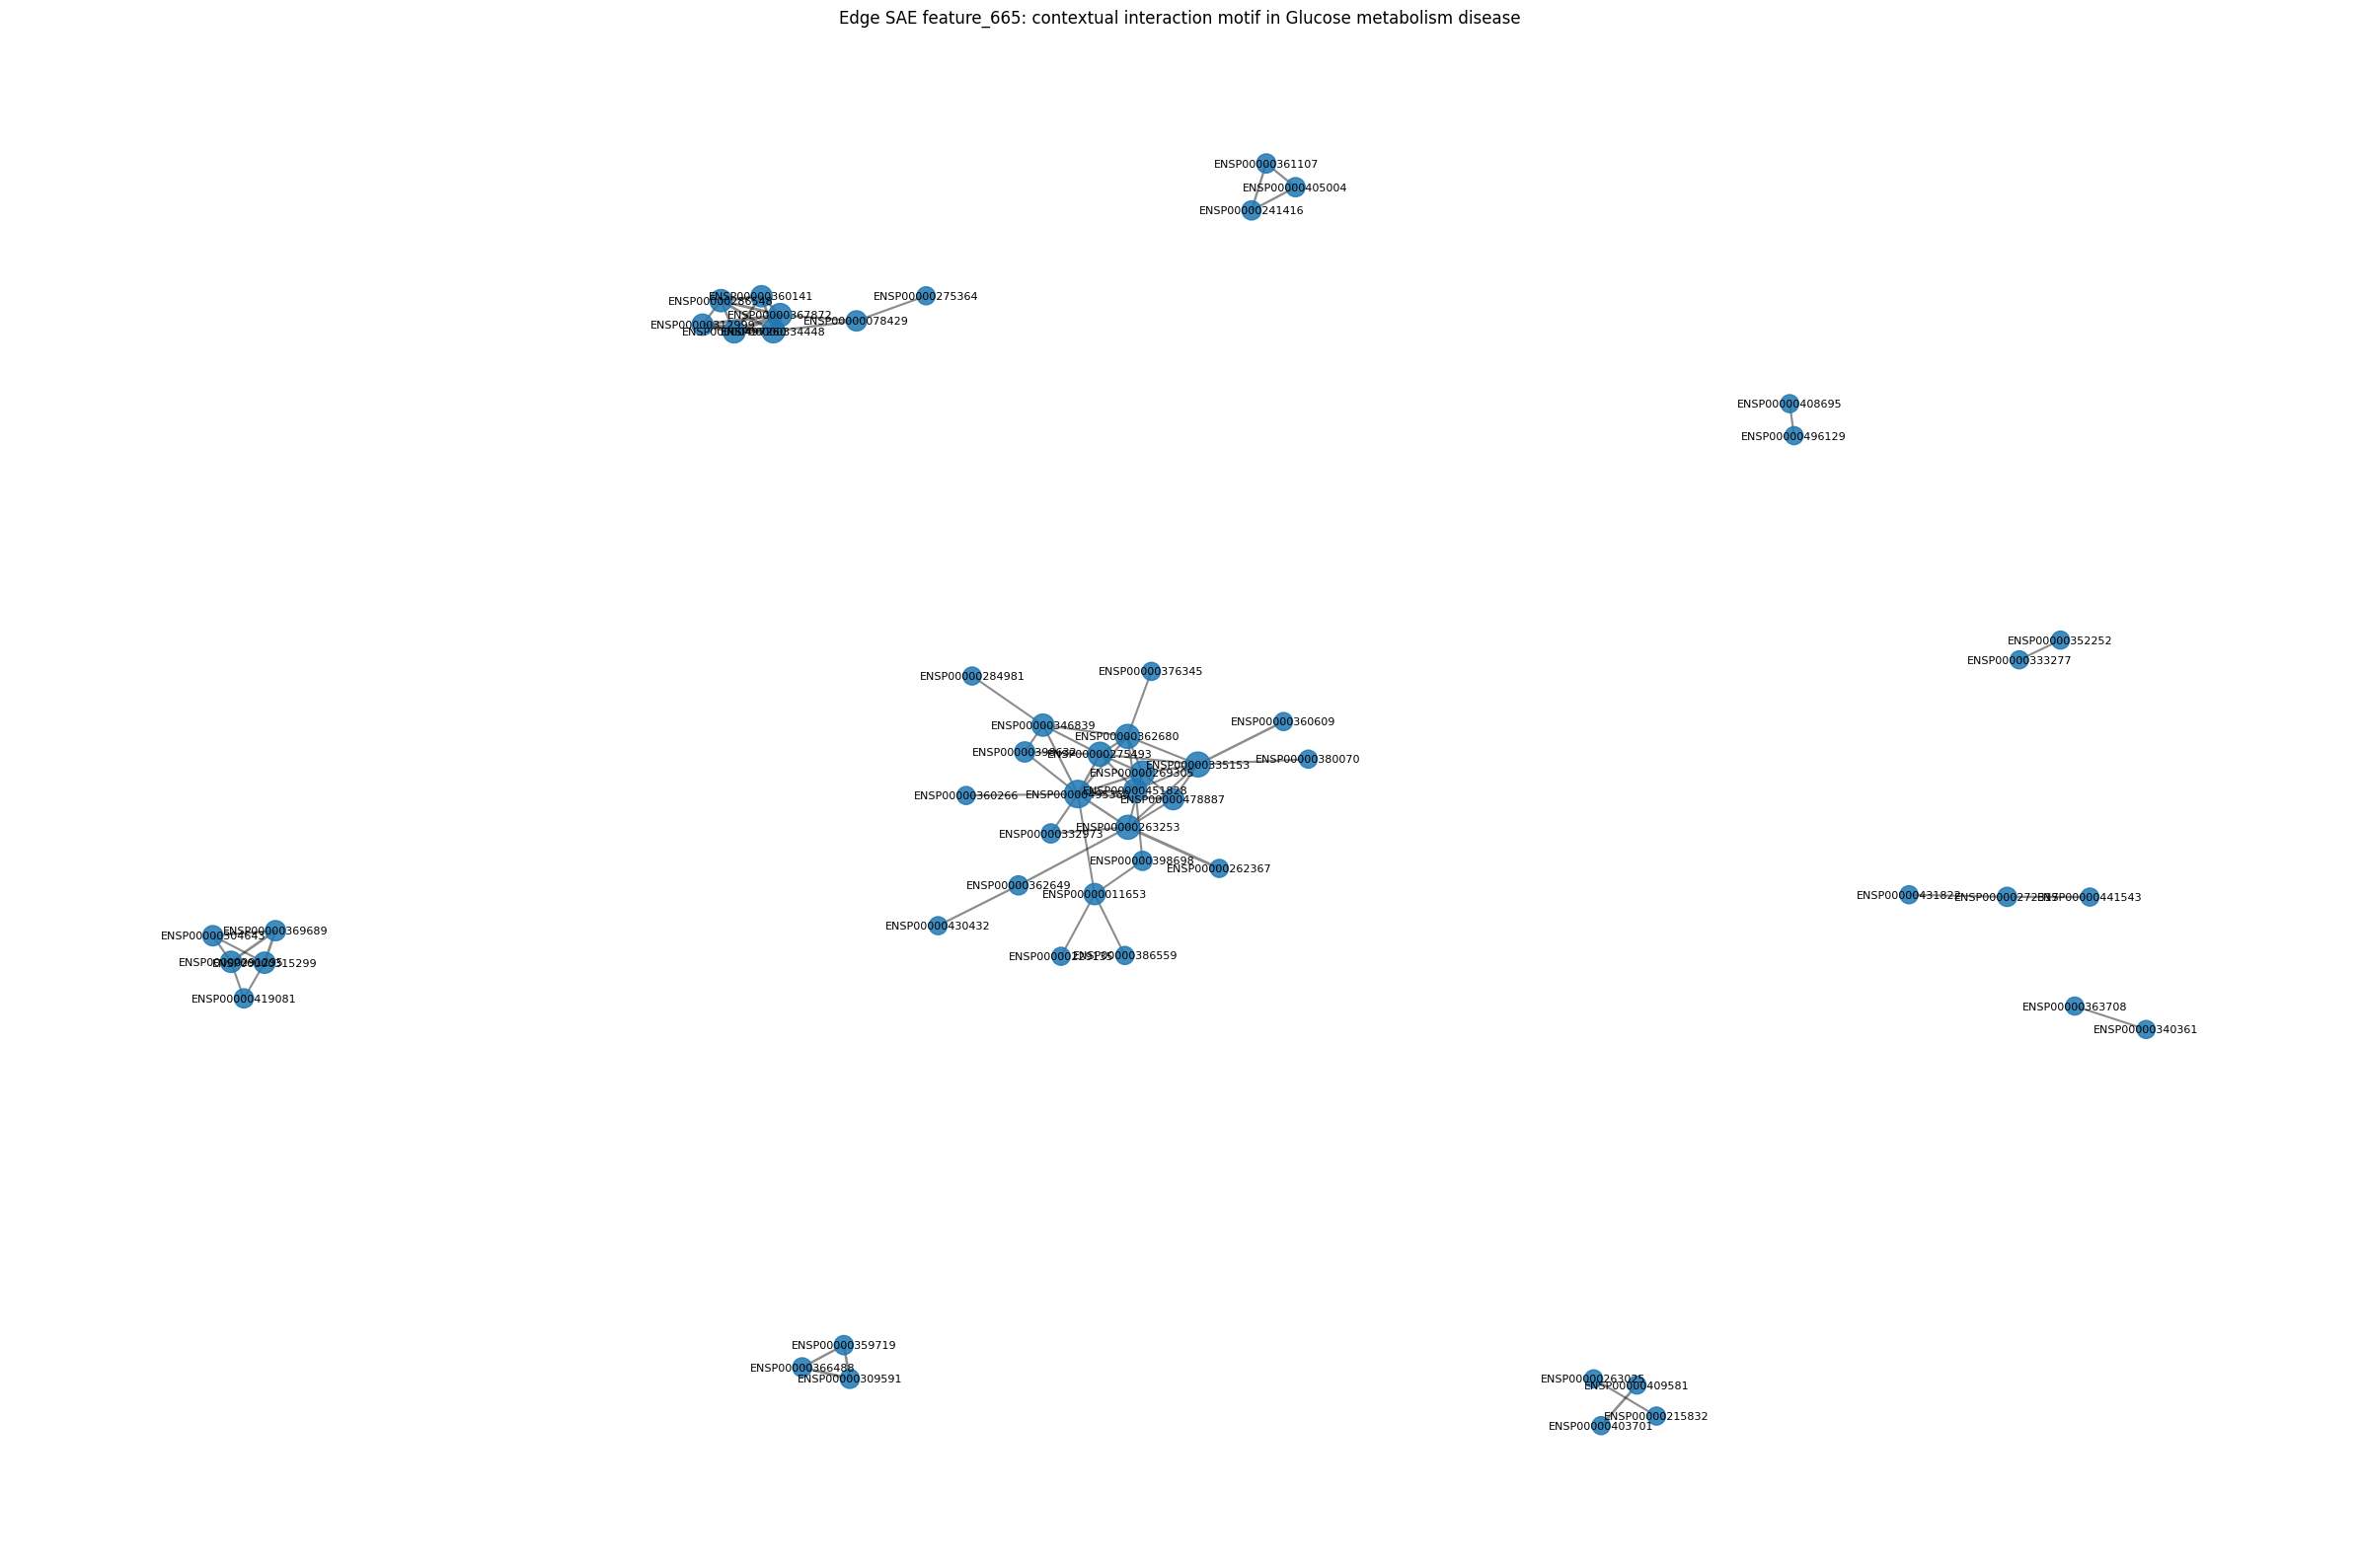

In [24]:
# A compact motif view for the selected edge feature in the disease where its activation is strongest.
if len(edge_case_rows):
    motif_doid = edge_case_rows.iloc[0]["doid"]
    motif_edges = collect_top_edges_for_feature(EDGE_FEATURE_FOR_CASE, doid=motif_doid, top_n=80)
    G_edge = nx.Graph()
    for row in motif_edges.itertuples(index=False):
        G_edge.add_edge(row.protein_a, row.protein_b, activation=row.activation)

    if G_edge.number_of_edges():
        centrality = nx.degree_centrality(G_edge)
        pos = nx.spring_layout(G_edge, seed=SEED)
        edge_widths = [1 + 4 * G_edge[u][v]["activation"] / max(motif_edges["activation"].max(), 1e-9)
                       for u, v in G_edge.edges()]
        node_sizes = [150 + 1200 * centrality[n] for n in G_edge.nodes()]

        fig, ax = plt.subplots(figsize=(24, 16))
        nx.draw_networkx_edges(G_edge, pos, width=edge_widths, alpha=0.45, ax=ax)
        nx.draw_networkx_nodes(G_edge, pos, node_size=node_sizes, alpha=0.85, ax=ax)
        nx.draw_networkx_labels(G_edge, pos, font_size=8, ax=ax)
        ax.set_title(
            f"Edge SAE feature_{EDGE_FEATURE_FOR_CASE}: contextual interaction motif in {disease_names.get(motif_doid, motif_doid)}"
        )
        ax.axis("off")
        plt.tight_layout(); plt.show()

### 7. Final biological interpretation

The complete analysis now keeps the three explanatory levels distinct:

\[
\boxed{
\textbf{Graph SAE} \rightarrow \text{network programs}
}
\]

\[
\boxed{
\textbf{Graph-program localization} \rightarrow \text{candidate proteins and interactions expressing the program}
}
\]

\[
\boxed{
\textbf{Node SAE} \rightarrow \text{contextual protein states}
}
\qquad
\boxed{
\textbf{Edge SAE} \rightarrow \text{contextual interaction states/motifs}
}
\]

The first three are complementary questions rather than stages of the same decoder:

- **Graph SAE:** *What recurring network programs exist across diseases?*
- **Localization:** *Where in the interactome is a selected program expressed?*
- **Node SAE:** *What latent protein states recur, and how do they change with disease context?*
- **Edge SAE:** *What latent interaction states recur, and how do they change with disease context?*

Ontology/pathway enrichment should be used at the end to **characterize and validate** these discovered structures, not to define them a priori.

### Recommended interpretation hierarchy

A strong case study should therefore read as:

**disease context → latent network program → localized network region → contextual protein/interaction states → biological characterization.**

None of the attribution scores above establish causality; they identify candidate mechanistic structure in the learned representation.